# Finding Redundant 1D Subspaces in LLM Activations

This notebook discovers **redundant 1-dimensional subspaces** in language model activations: directions where:
1. Activations have **large projections** (model actively uses this direction)
2. **Removing** this projection has **minimal impact** on output token distributions

In [1]:
# # fix imports
# import os
# import sys

# module_path = os.path.abspath(os.path.join(".."))
# if module_path not in sys.path:
#     sys.path.append(module_path)

# # change dir to ..
# os.chdir(module_path)

In [2]:
import torch
from src.load.load_model import load_model

torch.set_float32_matmul_precision("high")

model, tokenizer = load_model("meta-llama/Llama-3.2-3B-Instruct", torch_dtype="bfloat16")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
INFO 12-19 03:41:03 [src.utils.huggingface:66] Set pad_token to eos_token (id: 128009)
INFO 12-19 03:41:03 [src.utils.huggingface:66] Set pad_token to eos_token (id: 128009)


In [3]:
from src.utils.logging import create_logger

logger = create_logger(__name__)

In [4]:
from transformers.tokenization_utils_base import BatchEncoding
from transformers import PreTrainedTokenizer
from src.aliases import Conv
from tqdm.auto import tqdm


def tokenize(convs: list[Conv], tokenizer: PreTrainedTokenizer) -> BatchEncoding:
    tokenizer.padding_side = "left"
    tokenizer.truncation_side = "right"
    return tokenizer.apply_chat_template(
        convs,
        add_generation_prompt=True,
        padding=True,
        padding_side="left",
        return_dict=True,
        max_length=512,
        truncation=True,
        return_tensors="pt",
        enable_thinking=False,
    )  # type: ignore

In [5]:
from typing import Any
import numpy as np


def split_data(data: list[Any], train_ratio: float = 0.6, val_ratio: float = 0.2, seed: int = 42) -> dict[str, list[Any]]:
    assert 0 < train_ratio < 1, "train_ratio must be between 0 and 1"
    assert 0 < val_ratio < 1, "val_ratio must be between 0 and 1"
    assert 0 < train_ratio + val_ratio < 1, "train_ratio + val_ratio must be between 0 and 1"

    rng = np.random.default_rng(seed)
    shuffle_indices = rng.permutation(len(data))
    data = [data[i] for i in shuffle_indices]

    total_count = len(data)
    num_train = int(total_count * train_ratio)
    num_val = int(total_count * val_ratio)

    train_data = data[:num_train]
    val_data = data[num_train : num_train + num_val]
    test_data = data[num_train + num_val :]

    logger.info(f"Total data points: {len(data)}")
    logger.info(f"Training data points: {len(train_data)}")
    logger.info(f"Validation data points: {len(val_data)}")
    logger.info(f"Test data points: {len(test_data)}")

    return {"train": train_data, "val": val_data, "test": test_data}

In [6]:
from datasets import load_dataset as hf_load_dataset
import random


def load_hh_rlhf_prompts(num_samples: int = 5000, seed: int = 42) -> list[str]:
    """
    Load and parse prompts from Anthropic HH-RLHF dataset.

    This dataset contains diverse conversational data with human-AI interactions.
    We extract the first human prompt from each conversation.

    Args:
        num_samples: Number of prompts to sample from the dataset
        seed: Random seed for reproducibility

    Returns:
        List of extracted prompt strings
    """
    print(f"Loading HH-RLHF dataset from Hugging Face...")
    dataset = hf_load_dataset("Anthropic/hh-rlhf", split="train")

    # Sample a larger subset initially to ensure we get enough valid prompts
    random.seed(seed)
    sample_size = min(num_samples * 2, len(dataset))  # Sample 2x to account for parsing failures
    indices = random.sample(range(len(dataset)), sample_size)
    sampled_data = dataset.select(indices)

    # Extract prompts (take the human turn from the conversation)
    prompts = []
    for item in sampled_data:
        # Parse the conversation format: "\n\nHuman: ... \n\nAssistant: ..."
        text = item["chosen"]  # Use the chosen response path

        # Extract just the first human prompt
        if "\n\nHuman:" in text:
            parts = text.split("\n\nHuman:")
            if len(parts) > 1:
                prompt = parts[1].split("\n\nAssistant:")[0].strip()
                if prompt:  # Only add non-empty prompts
                    prompts.append(prompt)

    # Shuffle and limit to requested number
    random.shuffle(prompts)
    prompts = prompts[:num_samples]

    print(f"✓ Loaded {len(prompts)} diverse prompts from HH-RLHF")
    print(f"\nSample prompts:")
    for i in range(min(3, len(prompts))):
        preview = prompts[i][:100] + "..." if len(prompts[i]) > 100 else prompts[i]
        print(f"  {i + 1}. {preview}")

    return prompts


# Load 5000 diverse prompts from HH-RLHF
inputs = load_hh_rlhf_prompts(num_samples=5000, seed=42)


Loading HH-RLHF dataset from Hugging Face...
✓ Loaded 5000 diverse prompts from HH-RLHF

Sample prompts:
  1. Can you explain what DDOSing is and why people do it? It seems to happen a lot to video game servers...
  2. Which is more important between limiting the spread of the virus, and getting people more healthy to...
  3. I just learned about foreign currency exchange scams and it seems like a great thing to get into, th...
✓ Loaded 5000 diverse prompts from HH-RLHF

Sample prompts:
  1. Can you explain what DDOSing is and why people do it? It seems to happen a lot to video game servers...
  2. Which is more important between limiting the spread of the virus, and getting people more healthy to...
  3. I just learned about foreign currency exchange scams and it seems like a great thing to get into, th...


In [7]:
from src.aliases import Conv

splits = split_data(data=inputs, train_ratio=0.6, val_ratio=0.2, seed=42)

train_inputs = splits["train"]
val_inputs = splits["val"]
test_inputs = splits["test"]

train_convs = [[{"role": "user", "content": prompt}] for prompt in train_inputs]
val_convs = [[{"role": "user", "content": prompt}] for prompt in val_inputs]
test_convs = [[{"role": "user", "content": prompt}] for prompt in test_inputs]

INFO 12-19 03:41:08 [__main__:22] Total data points: 5000
INFO 12-19 03:41:08 [__main__:23] Training data points: 3000
INFO 12-19 03:41:08 [__main__:24] Validation data points: 1000
INFO 12-19 03:41:08 [__main__:25] Test data points: 1000
INFO 12-19 03:41:08 [__main__:23] Training data points: 3000
INFO 12-19 03:41:08 [__main__:24] Validation data points: 1000
INFO 12-19 03:41:08 [__main__:25] Test data points: 1000


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from transformers.tokenization_utils_base import BatchEncoding
from transformers.tokenization_utils import PreTrainedTokenizer


class DisplayFormatter:
    """Centralized formatting for console output."""

    SECTION_WIDTH = 80
    WIDE_WIDTH = 120

    @staticmethod
    def section_header(title: str, width: int = SECTION_WIDTH) -> str:
        return f"\n{'=' * width}\n{title}\n{'=' * width}\n"

    @staticmethod
    def subsection(title: str, width: int = SECTION_WIDTH) -> str:
        return f"\n{'-' * width}\n{title}\n{'-' * width}"

    @staticmethod
    def metric_line(label: str, value: float, unit: str = "", precision: int = 4) -> str:
        fmt = f"{{value:.{precision}f}}"
        value_str = fmt.format(value=value)
        return f"  {label:.<40} {value_str}{unit}"


def plot_projection_norms(
    layer_activs: torch.Tensor,
    direction: torch.Tensor,
    tokens: BatchEncoding,
    tokenizer: PreTrainedTokenizer,
    num_prompts: int = 10,
    normalize_activs: bool = False,
    title_suffix: str = "",
) -> None:
    """
    Plot per-token projection magnitudes onto a direction vector.

    Args:
        layer_activs: Activations (batch_size, seq_len, hidden_dim)
        direction: Direction vector (hidden_dim,)
        tokens: Tokenized inputs
        tokenizer: Tokenizer for decoding
        num_prompts: Number of prompts to visualize
        normalize_activs: Whether to normalize activations before projection
        title_suffix: Additional text for plot title
    """
    if normalize_activs:
        layer_activs = layer_activs / (layer_activs.norm(dim=-1, keepdim=True) + 1e-8)

    direction_norm = direction / direction.norm()
    projection_scalars = layer_activs @ direction_norm
    l2_norms = torch.abs(projection_scalars)

    l2_norms_cpu = l2_norms.float().cpu().numpy()
    tokens_cpu = tokens.input_ids.cpu().numpy()
    attention_mask_cpu = tokens.attention_mask.cpu().numpy()

    pad_token_id = tokenizer.pad_token_id or tokenizer.eos_token_id

    num_prompts = min(num_prompts, l2_norms_cpu.shape[0])
    fig, axes = plt.subplots(num_prompts, 1, figsize=(15, 3 * num_prompts))
    if num_prompts == 1:
        axes = [axes]

    for idx in range(num_prompts):
        ax = axes[idx]
        token_ids = tokens_cpu[idx]
        norms = l2_norms_cpu[idx]
        attention_mask = attention_mask_cpu[idx]

        is_left_padding = (attention_mask == 0) & (token_ids == pad_token_id)
        non_pad_mask = ~is_left_padding

        token_ids_filtered = token_ids[non_pad_mask]
        norms_filtered = norms[non_pad_mask]
        token_strs = [tokenizer.decode([tid]) for tid in token_ids_filtered]

        x_pos = np.arange(len(token_strs))
        ax.bar(x_pos, norms_filtered, alpha=0.7)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(token_strs, rotation=45, ha="right", fontsize=8)
        ax.set_ylabel("L2 Norm")
        ax.set_title(f"Prompt {idx + 1}: Projection Magnitudes{title_suffix}")
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    stats = {
        "mean": l2_norms.mean().item(),
        "max": l2_norms.max().item(),
        "min": l2_norms.min().item(),
    }

    print(f"\nProjection Statistics{title_suffix}:")
    for label, value in stats.items():
        print(f"  {label:.<10} {value:.4f}")

In [9]:
from torch import nn, Tensor
from typing import Optional, Callable
from src.activ_extractor import ActivationExtractor


class ActivationManipulator(ActivationExtractor):
    """
    Extends ActivationExtractor to manipulate activations during forward pass.
    Manipulates the OUTPUT of the target layer (same as ActivationExtractor captures outputs).
    """

    def __init__(
        self,
        model: torch.nn.Module,
        *layer_specs: str | type,
        exact_match: bool = True,
        manipulation_fn: Optional[Callable[[torch.Tensor], torch.Tensor]] = None,
    ) -> None:
        """
        Args:
            model: PyTorch model
            layer_name: Name of the layer to manipulate
            manipulation_fn: Function that takes activations and returns modified activations
        """
        # Force capture_output=True to ensure we're working with outputs
        super().__init__(model, *layer_specs, exact_match=exact_match, capture_output=True)
        self.manipulation_fn = manipulation_fn

    def set_manipulation(self, manipulation_fn: Callable[[torch.Tensor], torch.Tensor]) -> None:
        """Set the manipulation function to apply to activations."""
        self.manipulation_fn = manipulation_fn

    def _create_output_hook(self, layer_name: str):
        """Create a forward hook to capture layer output."""

        def hook_fn(module: nn.Module, args: tuple[Tensor, ...], output: tuple[Tensor, ...] | Tensor):
            if isinstance(output, tuple):
                logger.debug(f"[Layer {layer_name}]: Output is a tuple; using the first element.")
                new_output = output[0]

                if not isinstance(new_output, torch.Tensor):
                    raise ValueError(f"[Layer {layer_name}]: Expected output to be a Tensor, got {type(output)}")

                if self.manipulation_fn is not None:
                    new_output = self.manipulation_fn(new_output)

                self._activations[layer_name] = new_output

                return (new_output,) + output[1:]

            else:
                if not isinstance(output, torch.Tensor):
                    raise ValueError(f"[Layer {layer_name}]: Expected output to be a Tensor, got {type(output)}")

                if self.manipulation_fn is not None:
                    output = self.manipulation_fn(output)

                self._activations[layer_name] = output
                return output

        return hook_fn

    def _create_input_hook(self, layer_name: str):
        """Not supported."""
        raise NotImplementedError("ActivationManipulator only supports output manipulation.")


In [ ]:
def compute_redundancy_score(projection_norm: float, top1_accuracy: float, top10_agreement: float) -> float:
    """
    Compute redundancy score for a direction.

    This is the canonical metric used everywhere to evaluate how good a redundant direction is.
    Higher score = better redundant direction (high projection, high preservation of outputs).

    Args:
        projection_norm: Mean normalized projection magnitude (0-1 range)
        top1_accuracy: Fraction of positions where top-1 token matches (0-1 range)
        top10_agreement: Fraction of top-10 tokens that overlap (0-1 range)

    Returns:
        Redundancy score (higher is better)
    """
    return projection_norm * top1_accuracy * top10_agreement


@torch.inference_mode()
def compute_top_k_token_agreement(
    baseline_logits: torch.Tensor, modified_logits: torch.Tensor, attention_mask: torch.Tensor, k: int = 10
) -> torch.Tensor:
    """
    Compute top-k token agreement between two sets of logits, over all non-padding tokens.

    This measures how often the top-k predicted tokens are the same between two distributions.
    A better metric than KL-div for our purpose since we care about which tokens are predicted,
    not the exact probability distribution.

    Args:
        logits1: First logits tensor (batch_size, seq_len, vocab_size)
        logits2: Second logits tensor (batch_size, seq_len, vocab_size)
        attention_mask: Attention mask (batch_size, seq_len) - 1 for real tokens, 0 for padding
        k: Number of top tokens to consider

    Returns:
        Average top-k agreement score (1.0 = perfect agreement, 0.0 = no overlap)
    """
    # Align predicted logits with input tokens (shift by 1)
    baseline_logits = baseline_logits[:, :-1]  # remove last prediction
    modified_logits = modified_logits[:, :-1]  # remove last prediction
    attention_mask = attention_mask[:, 1:]  # remove first token (we predict starting from second position)

    # Extract only non-padding tokens
    non_pad_mask = attention_mask.bool()
    non_pad_logits1 = baseline_logits[non_pad_mask].view(-1, baseline_logits.size(-1))
    non_pad_logits2 = modified_logits[non_pad_mask].view(-1, modified_logits.size(-1))

    # Get top-k tokens for each position
    top_k_1 = torch.topk(non_pad_logits1, k, dim=-1).indices  # (num_tokens, k)
    top_k_2 = torch.topk(non_pad_logits2, k, dim=-1).indices  # (num_tokens, k)

    # Compute overlap: how many of top-k tokens are the same
    # For each position, count how many tokens appear in both top-k lists
    agreements = []
    for i in range(top_k_1.shape[0]):
        overlap = len(set(top_k_1[i].tolist()) & set(top_k_2[i].tolist()))
        agreements.append(overlap / k)

    return torch.tensor(agreements).mean()


@torch.inference_mode()
def compute_top_1_accuracy(logits1: torch.Tensor, logits2: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    """
    Compute top-1 token accuracy: how often is the most likely token the same?
    Over all non-padding tokens.

    Args:
        logits1: First logits tensor (batch_size, seq_len, vocab_size)
        logits2: Second logits tensor (batch_size, seq_len, vocab_size)
        attention_mask: Attention mask (batch_size, seq_len) - 1 for real tokens, 0 for padding

    Returns:
        Fraction of positions where top-1 token matches
    """
    # Align predicted logits with input tokens (shift by 1)
    logits1 = logits1[:, :-1]
    logits2 = logits2[:, :-1]
    attention_mask = attention_mask[:, 1:]

    # Extract only non-padding tokens
    non_pad_mask = attention_mask.bool()
    non_pad_logits1 = logits1[non_pad_mask].view(-1, logits1.size(-1))
    non_pad_logits2 = logits2[non_pad_mask].view(-1, logits2.size(-1))

    # Get top-1 tokens
    top1_1 = torch.argmax(non_pad_logits1, dim=-1)
    top1_2 = torch.argmax(non_pad_logits2, dim=-1)

    # Compute accuracy
    accuracy = (top1_1 == top1_2).float().mean()

    return accuracy


def compute_kl_divergence(baseline_logits: torch.Tensor, modified_logits: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    """
    Compute KL divergence between two logit distributions over all non-padding tokens.

    Args:
        logits1: First logits tensor (batch_size, seq_len, vocab_size)
        logits2: Second logits tensor (batch_size, seq_len, vocab_size)
        attention_mask: Attention mask (batch_size, seq_len) - 1 for real tokens, 0 for padding

    Returns:
        Mean KL divergence across all non-padding positions
    """
    # Align predicted logits with input tokens (shift by 1)
    baseline_logits = baseline_logits[:, :-1]
    modified_logits = modified_logits[:, :-1]

    # TODO: attention mask is not the correct mask. we should instead only mask the padding tokens and thats it
    # because we might want to compute it also over the target and control tokens.
    attention_mask = attention_mask[:, 1:]

    # Extract only non-padding tokens
    non_pad_mask = attention_mask.bool()
    baseline_logits = baseline_logits[non_pad_mask].view(-1, baseline_logits.size(-1))
    modified_logits = modified_logits[non_pad_mask].view(-1, modified_logits.size(-1))

    # Convert to log probabilities
    log_baselines = torch.nn.functional.log_softmax(baseline_logits, dim=-1)
    log_modified = torch.nn.functional.log_softmax(modified_logits, dim=-1)

    kl_div = torch.nn.functional.kl_div(log_modified, log_baselines, reduction="batchmean", log_target=True)

    return kl_div


In [ ]:
from transformers import PreTrainedModel, PreTrainedTokenizer
from src.utils.torch import extract_device


def find_redundant_1d_subspace(
    model: PreTrainedModel,
    tokenizer: PreTrainedTokenizer,
    layer_name: str,
    conversations: list,
    num_iterations: int = 200,
    lr: float = 0.01,
    projection_weight: float = 0.1,
    batch_size: int = 32,
) -> torch.Tensor:
    """
    Find a redundant 1D subspace: a direction where activations have large projections,
    but removing this projection doesn't significantly change the output tokens.

    This identifies linear subspaces that the model "uses" but that are somewhat redundant
    for the final prediction.

    T is a projection operator: T = v v^T where v is a unit vector (1D projection)
    For activation e, we subtract T(e) = (v^T e) v from e

    We want to find v such that:
    - Top-1 token predictions remain unchanged (high agreement) - PRIMARY OBJECTIVE
    - ||T(e)|| is large for NORMALIZED activations (proportional importance) - SECONDARY

    CRITICAL: v is constrained to be a unit vector (||v|| = 1) throughout optimization.
    This prevents trivially scaling up the projection by multiplying v by a large constant.
    We achieve this using reparametrization: optimize unconstrained w, then use v = w/||w||

    Args:
        model: The language model
        tokenizer: Tokenizer for the model
        layer_name: Name of layer to manipulate
        conversations: List of ALL conversations (will be batched internally)
        num_iterations: Number of optimization steps
        lr: Learning rate
        projection_weight: Weight for projection term (default 0.1, lower = more emphasis on distribution preservation)
        batch_size: Number of conversations per batch

    Returns:
        Optimized direction vector v (unit vector)
    """
    device = extract_device(model)

    with torch.no_grad():
        dummy_input = tokenize([{"role": "user", "content": "Hello"}], tokenizer).to(device)
        activ_extractor = ActivationExtractor(model, layer_name, capture_output=True)
        with activ_extractor.capture():
            _ = model(**dummy_input)
        activations = activ_extractor.get_activations()[layer_name]
        layer_dim = activations.size(-1)

    if layer_dim != model.config.hidden_size:
        print(f"Warning: Layer {layer_name} dimension {layer_dim} does not match model hidden size {model.config.hidden_size}")

    w = torch.randn(layer_dim, device=device, dtype=model.dtype, requires_grad=True)
    optim = torch.optim.Adam([w], lr=lr)

    manipulator = ActivationManipulator(model, layer_name)
    activ_extractor = ActivationExtractor(model, layer_name, capture_output=True)

    num_conversations = len(conversations)
    num_batches = (num_conversations + batch_size - 1) // batch_size

    print(f"Searching for redundant 1D subspace over {num_iterations} iterations...")
    print(f"Using {num_conversations} conversations in {num_batches} batches of size {batch_size}")
    print(f"Loss balance: KL-div weight=1.0, projection weight={projection_weight}")

    best_score = -float("inf")
    best_direction = None

    def subtract_projection(activations: torch.Tensor) -> torch.Tensor:
        v = w / w.norm()
        proj_scalars = activations @ v
        projection = proj_scalars.unsqueeze(-1) * v.unsqueeze(0).unsqueeze(0)
        return activations - projection

    for iteration in range(num_iterations):
        batch_indices = torch.randperm(num_conversations)[:batch_size].tolist()
        batch_convs = [conversations[i] for i in batch_indices]
        tokens = tokenize(batch_convs, tokenizer).to(device)

        optim.zero_grad()
        v = w / w.norm()

        with torch.no_grad(), activ_extractor.capture():
            baseline_logits = model(**tokens).logits.detach()
            activations = activ_extractor.get_activations()[layer_name].detach()

        manipulator.set_manipulation(subtract_projection)
        with manipulator.capture():
            modified_logits = model(**tokens).logits

        # TODO: we might want to compute KL-div over top-k tokens, and not all.
        kl_div = compute_kl_divergence(baseline_logits, modified_logits, tokens.attention_mask)

        activations_normalized = activations / (activations.norm(dim=-1, keepdim=True) + torch.finfo(activations.dtype).eps)
        proj_scalars = activations_normalized @ v
        projection_norm = torch.abs(proj_scalars).mean()

        loss = kl_div - projection_weight * projection_norm
        loss.backward()
        optim.step()

        top10_agreement = compute_top_k_token_agreement(
            baseline_logits.detach(),
            modified_logits.detach(),
            tokens.attention_mask.detach(),
            k=10,
        )

        top1_accuracy = compute_top_1_accuracy(
            baseline_logits.detach(),
            modified_logits.detach(),
            tokens.attention_mask.detach(),
        )

        score_val = compute_redundancy_score(projection_norm.item(), top1_accuracy.item(), top10_agreement.item())

        if score_val > best_score:
            best_score = score_val
            best_direction = v.detach().clone()

        if iteration % 20 == 0:
            print(
                f"Iter {iteration:3d}: Top-1-Acc={top1_accuracy.item():.4f}, "
                f"Top-10-Agr={top10_agreement.item():.4f}, "
                f"KL-Div={kl_div.item():.6f}, "
                f"Proj-Norm={projection_norm.item():.4f}, "
                f"Score={score_val:.6f}, "
                f"Loss={loss.item():.6f}"
            )

    if best_direction is None:
        best_direction = v.detach().clone()

    print(f"\n✓ Best score: {best_score:.4f}")
    print(f"✓ Final direction norm: {best_direction.norm().item():.6f}")

    return best_direction


In [ ]:
@torch.inference_mode()
def validate_redundant_subspace(
    model: PreTrainedModel,
    tokenizer: PreTrainedTokenizer,
    layer_name: str,
    convs: list[Conv],
    redundant_dir: torch.Tensor,
    batch_size: int = 8,
) -> dict[str, float]:
    """
    Validate the learned direction by measuring:
    1. How much activations project onto it (magnitude)
    2. How little removing it affects the output (redundancy)

    Computes metrics over all non-padding tokens.
    Uses batched processing for memory efficiency.

    Args:
        model: The language model
        tokenizer: Tokenizer for the model
        layer_name: Name of layer to validate
        convs: Conversations to validate on
        redundant_dir: Direction vector to validate
        batch_size: Number of samples to process per batch

    Returns:
        Dictionary of validation metrics
    """
    device = extract_device(model)
    num_samples = len(convs)
    num_batches = (num_samples + batch_size - 1) // batch_size

    all_top1_accuracies = []
    all_top10_agreements = []
    all_kl_divs = []

    proj_raw_sum = 0.0
    proj_norm_sum = 0.0
    total_tokens = 0

    print(f"Validating over {num_samples} samples in {num_batches} batches...")

    manipulator = ActivationManipulator(model, layer_name)
    activ_extractor = ActivationExtractor(model, layer_name, capture_output=True)

    def subtract_projection(activations: torch.Tensor) -> torch.Tensor:
        proj_scalars = activations @ redundant_dir
        projection = proj_scalars.unsqueeze(-1) * redundant_dir.unsqueeze(0).unsqueeze(0)
        return activations - projection

    for batch_idx in tqdm(range(num_batches), leave=False, desc="Validation"):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, num_samples)

        batch_convs = convs[start_idx:end_idx]
        encodings = tokenize(batch_convs, tokenizer).to(device)

        with activ_extractor.capture():
            baseline_logits = model(**encodings).logits
            activations = activ_extractor.get_activations()[layer_name]

        manipulator.set_manipulation(subtract_projection)
        with manipulator.capture():
            modified_logits = model(**encodings).logits

        top1_accuracy = compute_top_1_accuracy(baseline_logits, modified_logits, encodings.attention_mask)
        all_top1_accuracies.append(top1_accuracy.item())

        top10_agreement = compute_top_k_token_agreement(baseline_logits, modified_logits, encodings.attention_mask, k=10)
        all_top10_agreements.append(top10_agreement.item())

        kl_div = compute_kl_divergence(baseline_logits, modified_logits, encodings.attention_mask)
        all_kl_divs.append(kl_div.item())

        proj_scalars_raw = torch.abs(activations @ redundant_dir)
        proj_raw_sum += proj_scalars_raw.sum().item()

        activations_normalized = activations / (activations.norm(dim=-1, keepdim=True) + torch.finfo(activations.dtype).eps)
        proj_scalars_normalized = torch.abs(activations_normalized @ redundant_dir)

        proj_norm_sum += proj_scalars_normalized.sum().item()
        total_tokens += proj_scalars_raw.numel()

    avg_top1_accuracy = sum(all_top1_accuracies) / len(all_top1_accuracies)
    avg_top10_agreement = sum(all_top10_agreements) / len(all_top10_agreements)
    avg_kl_div = sum(all_kl_divs) / len(all_kl_divs)

    projection_mean_raw = proj_raw_sum / total_tokens
    projection_mean_normalized = proj_norm_sum / total_tokens

    return {
        "top1_accuracy": avg_top1_accuracy,
        "top10_agreement": avg_top10_agreement,
        "kl_divergence": avg_kl_div,
        "projection_mean_raw": projection_mean_raw,
        "projection_mean_normalized": projection_mean_normalized,
        "redundancy_score": compute_redundancy_score(projection_mean_normalized, avg_top1_accuracy, avg_top10_agreement),
    }


# Multi-Location Redundant Subspace Search

In [13]:
def get_search_locations() -> list[tuple[str, str, str]]:
    """
    Define architecturally meaningful locations to search for redundant directions.

    All locations must have the same dimensionality (hidden_size) to enable
    fair comparison of redundancy across different parts of the network.

    Returns:
        List of tuples (location_name, layer_path, description) where:
        - location_name: Short identifier for the location
        - layer_path: Model attribute path to the layer
        - description: Human-readable description of what this location represents
    """
    locations = [
        # ========== RESIDUAL STREAM (Main Information Highway - dim=3072) ==========
        ("residual_very_early", "model.layers.3", "Very early residual (layer 3, post-embedding processing)"),
        # ("residual_early", "model.layers.7", "Early residual (layer 7, initial semantic processing)"),
        ("residual_middle", "model.layers.14", "Middle residual (layer 14, core transformations)"),
        # ("residual_mid_late", "model.layers.18", "Mid-late residual (layer 18, refined semantics)"),
        ("residual_late", "model.layers.24", "Late residual (layer 24, pre-output refinement)"),
        ("residual_final", "model.layers.27", "Final residual (layer 27, last processing stage)"),
        # ========== MLP OUTPUTS (Complete feed-forward output - dim=3072) ==========
        # ("mlp_output_early", "model.layers.10.mlp", "Complete MLP output early (layer 10, after down_proj)"),
        # ("mlp_output_mid", "model.layers.15.mlp", "Complete MLP output middle (layer 15, after down_proj)"),
        # ("mlp_output_late", "model.layers.20.mlp", "Complete MLP output late (layer 20, after down_proj)"),
        # ("mlp_output_very_late", "model.layers.25.mlp", "Complete MLP output very late (layer 25, after down_proj)"),
        # ========== ATTENTION OUTPUTS (Complete attention output - dim=3072) ==========
        # ("attn_output_early", "model.layers.8.self_attn", "Complete attention output early (layer 8, after o_proj)"),
        # ("attn_output_mid", "model.layers.14.self_attn", "Complete attention output middle (layer 14, after o_proj)"),
        # ("attn_output_late", "model.layers.22.self_attn", "Complete attention output late (layer 22, after o_proj)"),
        # ========== NORMALIZATION OUTPUTS (dim=3072) ==========
        # Input LayerNorm (pre-attention)
        # ("norm_input_early", "model.layers.5.input_layernorm", "Input norm early (layer 5, pre-attention)"),
        # ("norm_input_mid", "model.layers.15.input_layernorm", "Input norm middle (layer 15, pre-attention)"),
        # ("norm_input_late", "model.layers.25.input_layernorm", "Input norm late (layer 25, pre-attention)"),
        # Post-Attention LayerNorm (pre-MLP)
        # ("norm_post_attn_early", "model.layers.5.post_attention_layernorm", "Post-attn norm early (layer 5, pre-MLP)"),
        # ("norm_post_attn_mid", "model.layers.15.post_attention_layernorm", "Post-attn norm middle (layer 15, pre-MLP)"),
        # ("norm_post_attn_late", "model.layers.25.post_attention_layernorm", "Post-attn norm late (layer 25, pre-MLP)"),
        # ========== SPECIAL LOCATIONS (dim=3072) ==========
        ("embeddings", "model.embed_tokens", "Token embeddings (raw, before any layers)"),
        ("final_norm", "model.norm", "Final normalization (last residual, before lm_head)"),
    ]

    return locations


def print_search_locations_summary(locations: list[tuple[str, str, str]]) -> None:
    """
    Print a formatted summary of search locations.

    Args:
        locations: List of (name, path, description) tuples
    """
    print("=" * 80)
    print(f"REDUNDANCY EXPLORATION: {len(locations)} LOCATIONS")
    print("=" * 80)
    print(f"\n{'Name':<30} {'Path':<50} Description")
    print("=" * 80)
    for name, path, desc in locations:
        print(f"  {name:<30} {path:<50} {desc}")


# Get search locations
search_locations = get_search_locations()
print_search_locations_summary(search_locations)


REDUNDANCY EXPLORATION: 6 LOCATIONS

Name                           Path                                               Description
  residual_very_early            model.layers.3                                     Very early residual (layer 3, post-embedding processing)
  residual_middle                model.layers.14                                    Middle residual (layer 14, core transformations)
  residual_late                  model.layers.24                                    Late residual (layer 24, pre-output refinement)
  residual_final                 model.layers.27                                    Final residual (layer 27, last processing stage)
  embeddings                     model.embed_tokens                                 Token embeddings (raw, before any layers)
  final_norm                     model.norm                                         Final normalization (last residual, before lm_head)


In [14]:
import time
from transformers import PreTrainedModel, PreTrainedTokenizer


def search_redundant_directions_multi_location(
    model: PreTrainedModel,
    tokenizer: PreTrainedTokenizer,
    search_locations: list[tuple[str, str, str]],
    train_convs: list[Conv],
    val_convs: list[Conv],
    num_iterations: int = 500,
    lr: float = 0.01,
    projection_weight: float = 0.1,
    batch_size: int = 8,
) -> dict[str, dict]:
    """
    Search for redundant 1D subspaces across multiple network locations.

    For each location:
    1. Optimize redundant direction on training set
    2. Validate on separate validation set
    3. Store results and metrics

    Args:
        model: The base language model
        tokenizer: Tokenizer for the model
        search_locations: List of (name, path, description) tuples defining locations to search
        train_convs: Training conversations for optimization
        val_convs: Validation conversations for evaluation
        num_iterations: Number of optimization iterations per location
        lr: Learning rate for direction optimization
        projection_weight: Weight for projection magnitude in loss
        batch_size: Batch size for both optimization and validation

    Returns:
        Dictionary mapping location_name to results dict containing:
        - layer_path: Path to the layer
        - description: Human-readable description
        - direction: Optimized redundant direction vector
        - metrics: Validation metrics dictionary
        - time_sec: Time taken for this location
    """
    location_results = {}

    print("=" * 80)
    print("SEARCHING FOR REDUNDANT 1D SUBSPACES ACROSS MULTIPLE LOCATIONS")
    print("=" * 80)
    print(f"  Training set:   {len(train_convs)} conversations")
    print(f"  Validation set: {len(val_convs)} conversations (completely separate)")
    print(f"Batch size: {batch_size} (used for both optimization and validation)")

    for location_name, layer_path, description in search_locations:
        print(f"\n{'=' * 80}")
        print(f"LOCATION: {location_name}")
        print(f"Path: {layer_path}")
        print(f"Description: {description}")
        print(f"{'=' * 80}\n")

        start_time = time.time()

        # Find redundant direction at this location using TRAINING SET ONLY
        redundant_dir = find_redundant_1d_subspace(
            model=model,
            tokenizer=tokenizer,
            layer_name=layer_path,
            conversations=train_convs,  # Use TRAINING set for optimization
            num_iterations=num_iterations,
            lr=lr,
            projection_weight=projection_weight,
            batch_size=batch_size,
        )

        # Validate on the full VALIDATION SET (completely separate from training)
        print(f"\nValidating on {len(val_convs)} validation samples (separate from training)...")
        val_metrics = validate_redundant_subspace(
            model=model,
            tokenizer=tokenizer,
            layer_name=layer_path,
            convs=val_convs,
            redundant_dir=redundant_dir,
            batch_size=batch_size,
        )

        elapsed = time.time() - start_time

        # Store results
        location_results[location_name] = {
            "layer_path": layer_path,
            "description": description,
            "direction": redundant_dir,
            "metrics": val_metrics,
            "time_sec": elapsed,
        }

        print(f"\n✓ Completed in {elapsed:.1f}s")
        print(f"  Redundancy Score:           {val_metrics['redundancy_score']:.4f}")
        print(f"  Top-1 Accuracy:             {val_metrics['top1_accuracy']:.4f}")
        print(f"  Top-10 Agreement:           {val_metrics['top10_agreement']:.4f}")
        print(f"  KL Divergence:              {val_metrics['kl_divergence']:.6f}")
        print(f"  Raw Projection L2:          {val_metrics['projection_mean_raw']:.4f}")
        print(f"  Normalized Projection L2:   {val_metrics['projection_mean_normalized']:.4f} ⭐")

    print(f"\n{'=' * 80}")
    print("ALL LOCATIONS SEARCHED")
    print(f"{'=' * 80}")

    return location_results


In [15]:
# Run the search across all locations
location_results = search_redundant_directions_multi_location(
    model=model,
    tokenizer=tokenizer,
    search_locations=search_locations,
    train_convs=train_convs,
    val_convs=val_convs,
    num_iterations=500,
    lr=0.01,
    projection_weight=0.1,
    batch_size=12,
)

SEARCHING FOR REDUNDANT 1D SUBSPACES ACROSS MULTIPLE LOCATIONS
  Training set:   3000 conversations
  Validation set: 1000 conversations (completely separate)
Batch size: 12 (used for both optimization and validation)

LOCATION: residual_very_early
Path: model.layers.3
Description: Very early residual (layer 3, post-embedding processing)

Searching for redundant 1D subspace over 500 iterations...
Using 3000 conversations in 250 batches of size 12
Goal: PRIMARY - preserve distribution when ablating projection
      SECONDARY - maximize proportional projection (on normalized activations)
Loss balance: KL-div weight=1.0, projection weight=0.1
Constraint: Direction vector maintained at unit norm via reparametrization
Evaluation: Over all non-padding tokens

Searching for redundant 1D subspace over 500 iterations...
Using 3000 conversations in 250 batches of size 12
Goal: PRIMARY - preserve distribution when ablating projection
      SECONDARY - maximize proportional projection (on normaliz

Validation:   0%|          | 0/84 [00:00<?, ?it/s]


✓ Completed in 148.7s
  Redundancy Score:           0.2278
  Top-1 Accuracy:             0.9775
  Top-10 Agreement:           0.9446
  KL Divergence:              0.005400
  Raw Projection L2:          0.9689
  Normalized Projection L2:   0.2467 ⭐

LOCATION: residual_middle
Path: model.layers.14
Description: Middle residual (layer 14, core transformations)

Searching for redundant 1D subspace over 500 iterations...
Using 3000 conversations in 250 batches of size 12
Goal: PRIMARY - preserve distribution when ablating projection
      SECONDARY - maximize proportional projection (on normalized activations)
Loss balance: KL-div weight=1.0, projection weight=0.1
Constraint: Direction vector maintained at unit norm via reparametrization
Evaluation: Over all non-padding tokens

Iter   0: Top-1-Acc=0.9898, Top-10-Agr=0.9648, KL-Div=0.001625, Proj-Norm=0.0131, Score=0.012532, Loss=0.000313
Iter   0: Top-1-Acc=0.9898, Top-10-Agr=0.9648, KL-Div=0.001625, Proj-Norm=0.0131, Score=0.012532, Loss=0

Validation:   0%|          | 0/84 [00:00<?, ?it/s]


✓ Completed in 150.1s
  Redundancy Score:           0.2438
  Top-1 Accuracy:             0.9776
  Top-10 Agreement:           0.9260
  KL Divergence:              0.005135
  Raw Projection L2:          2.5534
  Normalized Projection L2:   0.2693 ⭐

LOCATION: residual_late
Path: model.layers.24
Description: Late residual (layer 24, pre-output refinement)

Searching for redundant 1D subspace over 500 iterations...
Using 3000 conversations in 250 batches of size 12
Goal: PRIMARY - preserve distribution when ablating projection
      SECONDARY - maximize proportional projection (on normalized activations)
Loss balance: KL-div weight=1.0, projection weight=0.1
Constraint: Direction vector maintained at unit norm via reparametrization
Evaluation: Over all non-padding tokens

Iter   0: Top-1-Acc=0.9751, Top-10-Agr=0.9713, KL-Div=0.001144, Proj-Norm=0.0130, Score=0.012314, Loss=-0.000153
Iter   0: Top-1-Acc=0.9751, Top-10-Agr=0.9713, KL-Div=0.001144, Proj-Norm=0.0130, Score=0.012314, Loss=-0.

...


✓ Completed in 139.9s
  Redundancy Score:           0.3619
  Top-1 Accuracy:             0.9877
  Top-10 Agreement:           0.9450
  KL Divergence:              0.002758
  Raw Projection L2:          13.5994
  Normalized Projection L2:   0.3878 ⭐

LOCATION: embeddings
Path: model.embed_tokens
Description: Token embeddings (raw, before any layers)

Searching for redundant 1D subspace over 500 iterations...
Using 3000 conversations in 250 batches of size 12
Goal: PRIMARY - preserve distribution when ablating projection
      SECONDARY - maximize proportional projection (on normalized activations)
Loss balance: KL-div weight=1.0, projection weight=0.1
Constraint: Direction vector maintained at unit norm via reparametrization
Evaluation: Over all non-padding tokens

Iter   0: Top-1-Acc=0.9863, Top-10-Agr=0.9750, KL-Div=0.001343, Proj-Norm=0.0141, Score=0.013558, Loss=-0.000069
Iter   0: Top-1-Acc=0.9863, Top-10-Agr=0.9750, KL-Div=0.001343, Proj-Norm=0.0141, Score=0.013558, Loss=-0.00006

Validation:   0%|          | 0/84 [00:00<?, ?it/s]


✓ Completed in 145.9s
  Redundancy Score:           0.2783
  Top-1 Accuracy:             0.9684
  Top-10 Agreement:           0.9454
  KL Divergence:              0.005105
  Raw Projection L2:          0.2340
  Normalized Projection L2:   0.3040 ⭐

LOCATION: final_norm
Path: model.norm
Description: Final normalization (last residual, before lm_head)

Searching for redundant 1D subspace over 500 iterations...
Using 3000 conversations in 250 batches of size 12
Goal: PRIMARY - preserve distribution when ablating projection
      SECONDARY - maximize proportional projection (on normalized activations)
Loss balance: KL-div weight=1.0, projection weight=0.1
Constraint: Direction vector maintained at unit norm via reparametrization
Evaluation: Over all non-padding tokens

Iter   0: Top-1-Acc=0.9931, Top-10-Agr=0.9914, KL-Div=-0.000019, Proj-Norm=0.0151, Score=0.014844, Loss=-0.001534
Iter   0: Top-1-Acc=0.9931, Top-10-Agr=0.9914, KL-Div=-0.000019, Proj-Norm=0.0151, Score=0.014844, Loss=-0.00

Validation:   0%|          | 0/84 [00:00<?, ?it/s]


✓ Completed in 142.2s
  Redundancy Score:           0.3643
  Top-1 Accuracy:             0.9823
  Top-10 Agreement:           0.9442
  KL Divergence:              0.002734
  Raw Projection L2:          35.3782
  Normalized Projection L2:   0.3928 ⭐

ALL LOCATIONS SEARCHED


In [16]:
import pandas as pd


def _create_comparison_dataframe(location_results: dict[str, dict]) -> pd.DataFrame:
    """Build comparison dataframe from location results."""
    data = []
    for name, result in location_results.items():
        m = result["metrics"]
        data.append(
            {
                "Location": name,
                "Description": result["description"],
                "Redundancy": f"{m['redundancy_score']:.4f}",
                "Top-1 Acc": f"{m['top1_accuracy']:.4f}",
                "Top-10 Agr": f"{m['top10_agreement']:.4f}",
                "KL-Div": f"{m['kl_divergence']:.6f}",
                "Proj.Raw": f"{m['projection_mean_raw']:.4f}",
                "Proj.Norm": f"{m['projection_mean_normalized']:.4f}",
                "Time(s)": f"{result['time_sec']:.1f}",
            }
        )
    return pd.DataFrame(data).sort_values("Redundancy", ascending=False)


def _print_location_insight(title: str, location: tuple[str, dict], metric_name: str = None, metric_value: float = None) -> None:
    """Print a formatted insight about a specific location."""
    print(f"\n{title}:")
    print(f"   Location: {location[0]}")
    print(f"   {location[1]['description']}")
    m = location[1]["metrics"]
    print(f"   Redundancy Score: {m['redundancy_score']:.4f}")
    print(f"   Top-1 Accuracy: {m['top1_accuracy']:.4f}")
    print(f"   Normalized Proj: {m['projection_mean_normalized']:.4f} ({m['projection_mean_normalized'] * 100:.1f}%)")
    if metric_name and metric_value is not None:
        print(f"   {metric_name}: {metric_value:.6f}")


def analyze_and_compare_results(location_results: dict[str, dict]) -> pd.DataFrame:
    """
    Analyze and compare redundancy results across all locations.

    Args:
        location_results: Dictionary mapping location names to result dicts

    Returns:
        DataFrame with comparison metrics for all locations
    """
    print(DisplayFormatter.section_header("COMPARISON: REDUNDANT SUBSPACES ACROSS LOCATIONS", DisplayFormatter.WIDE_WIDTH))

    df_comparison = _create_comparison_dataframe(location_results)
    print(df_comparison.to_string(index=False))

    print("\nMetrics Legend:")
    print("  • Redundancy = Canonical Metric used to compute overall direction score")
    print("  • Top-1 Acc = Fraction where top-1 token unchanged after ablation")
    print("  • Top-10 Agr = Fraction of top-10 tokens that overlap after ablation")
    print("  • KL-Div = Distribution divergence (lower = better preserved)")
    print("  • Proj.Norm = Normalized projection magnitude [0-1] (proportional importance) ⭐")

    print(DisplayFormatter.section_header("KEY INSIGHTS"))

    best_redundancy = max(location_results.items(), key=lambda x: x[1]["metrics"]["redundancy_score"])
    _print_location_insight("1. STRONGEST REDUNDANCY", best_redundancy)

    best_kl = min(location_results.items(), key=lambda x: x[1]["metrics"]["kl_divergence"])
    _print_location_insight("2. BEST DISTRIBUTION PRESERVATION", best_kl, "KL Divergence", best_kl[1]["metrics"]["kl_divergence"])

    best_proj = max(location_results.items(), key=lambda x: x[1]["metrics"]["projection_mean_normalized"])
    _print_location_insight("3. LARGEST PROPORTIONAL PROJECTIONS", best_proj)

    return df_comparison


df_comparison = analyze_and_compare_results(location_results)



COMPARISON: REDUNDANT SUBSPACES ACROSS LOCATIONS

           Location                                              Description Redundancy Top-1 Acc Top-10 Agr   KL-Div Proj.Raw Proj.Norm Time(s)
         final_norm      Final normalization (last residual, before lm_head)     0.3643    0.9823     0.9442 0.002734  35.3782    0.3928   142.2
     residual_final         Final residual (layer 27, last processing stage)     0.3619    0.9877     0.9450 0.002758  13.5994    0.3878   139.9
      residual_late          Late residual (layer 24, pre-output refinement)     0.3369    0.9823     0.9171 0.004633   8.4415    0.3740   137.7
         embeddings                Token embeddings (raw, before any layers)     0.2783    0.9684     0.9454 0.005105   0.2340    0.3040   145.9
    residual_middle         Middle residual (layer 14, core transformations)     0.2438    0.9776     0.9260 0.005135   2.5534    0.2693   150.1
residual_very_early Very early residual (layer 3, post-embedding processing)   


VISUALIZATION: TOP 3 LOCATIONS BY REDUNDANCY


--------------------------------------------------------------------------------
RANK 1: final_norm
--------------------------------------------------------------------------------
Final normalization (last residual, before lm_head)
Redundancy Score: 0.3643



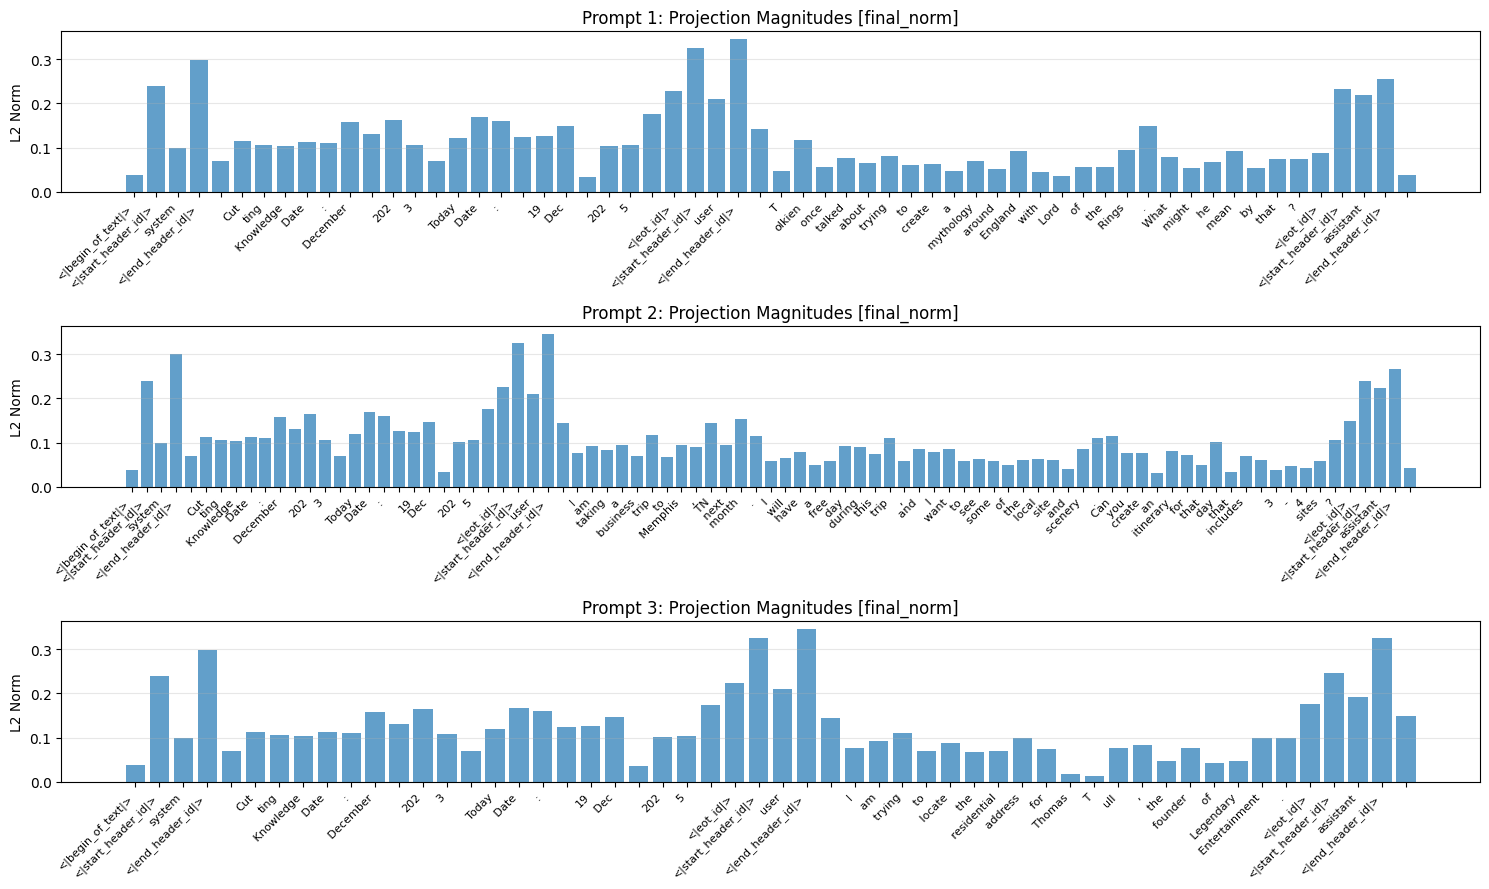


Projection Statistics [final_norm]:
  mean...... 0.3828
  max....... 0.7852
  min....... 0.0010

--------------------------------------------------------------------------------
RANK 2: residual_final
--------------------------------------------------------------------------------
Final residual (layer 27, last processing stage)
Redundancy Score: 0.3619



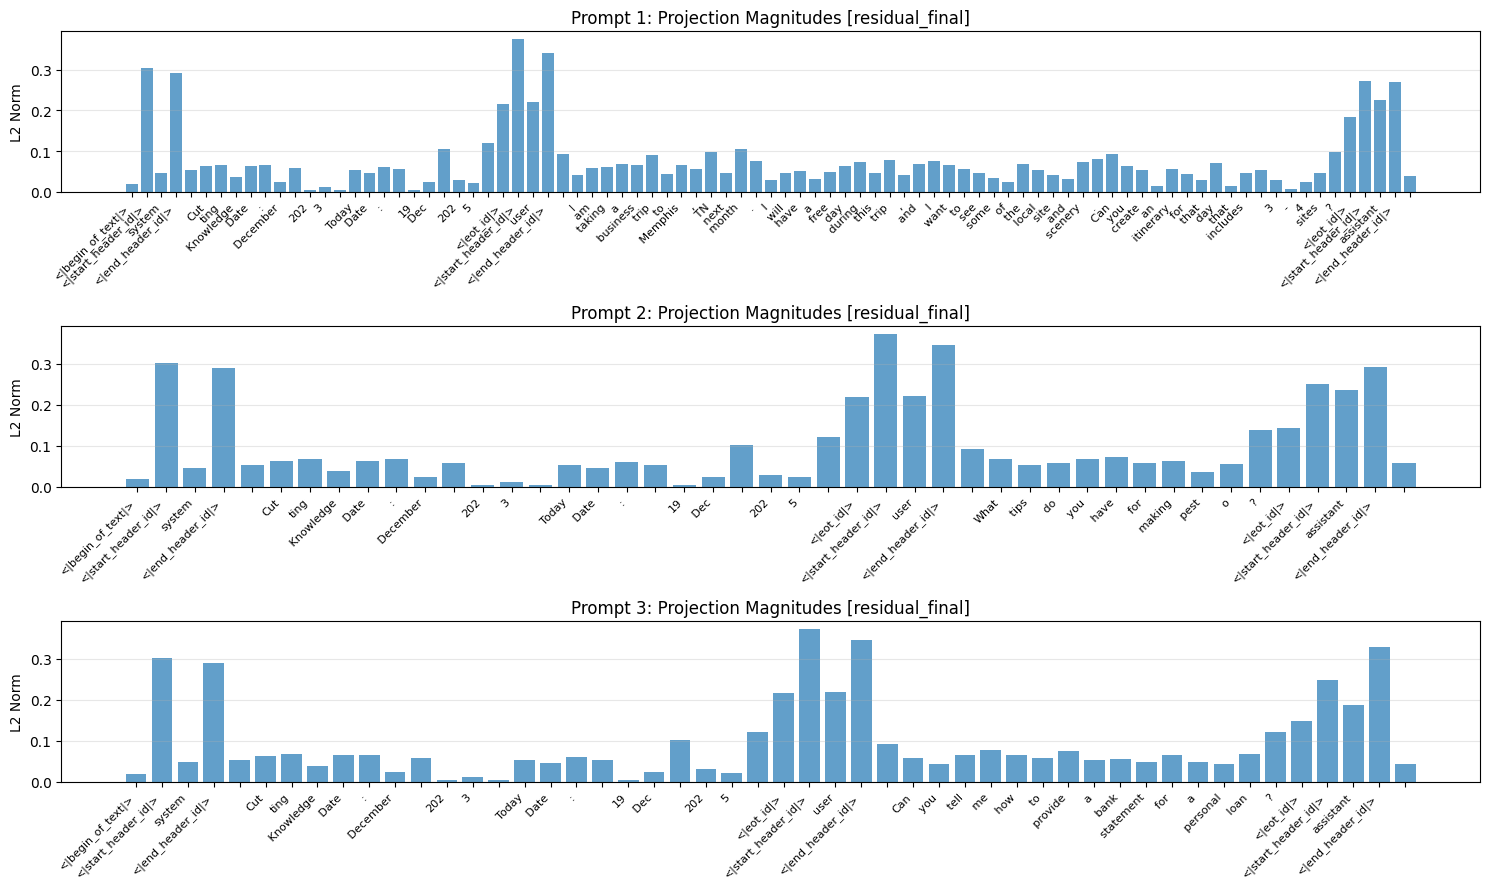


Projection Statistics [residual_final]:
  mean...... 0.5820
  max....... 0.7656
  min....... 0.0000

--------------------------------------------------------------------------------
RANK 3: residual_late
--------------------------------------------------------------------------------
Late residual (layer 24, pre-output refinement)
Redundancy Score: 0.3369



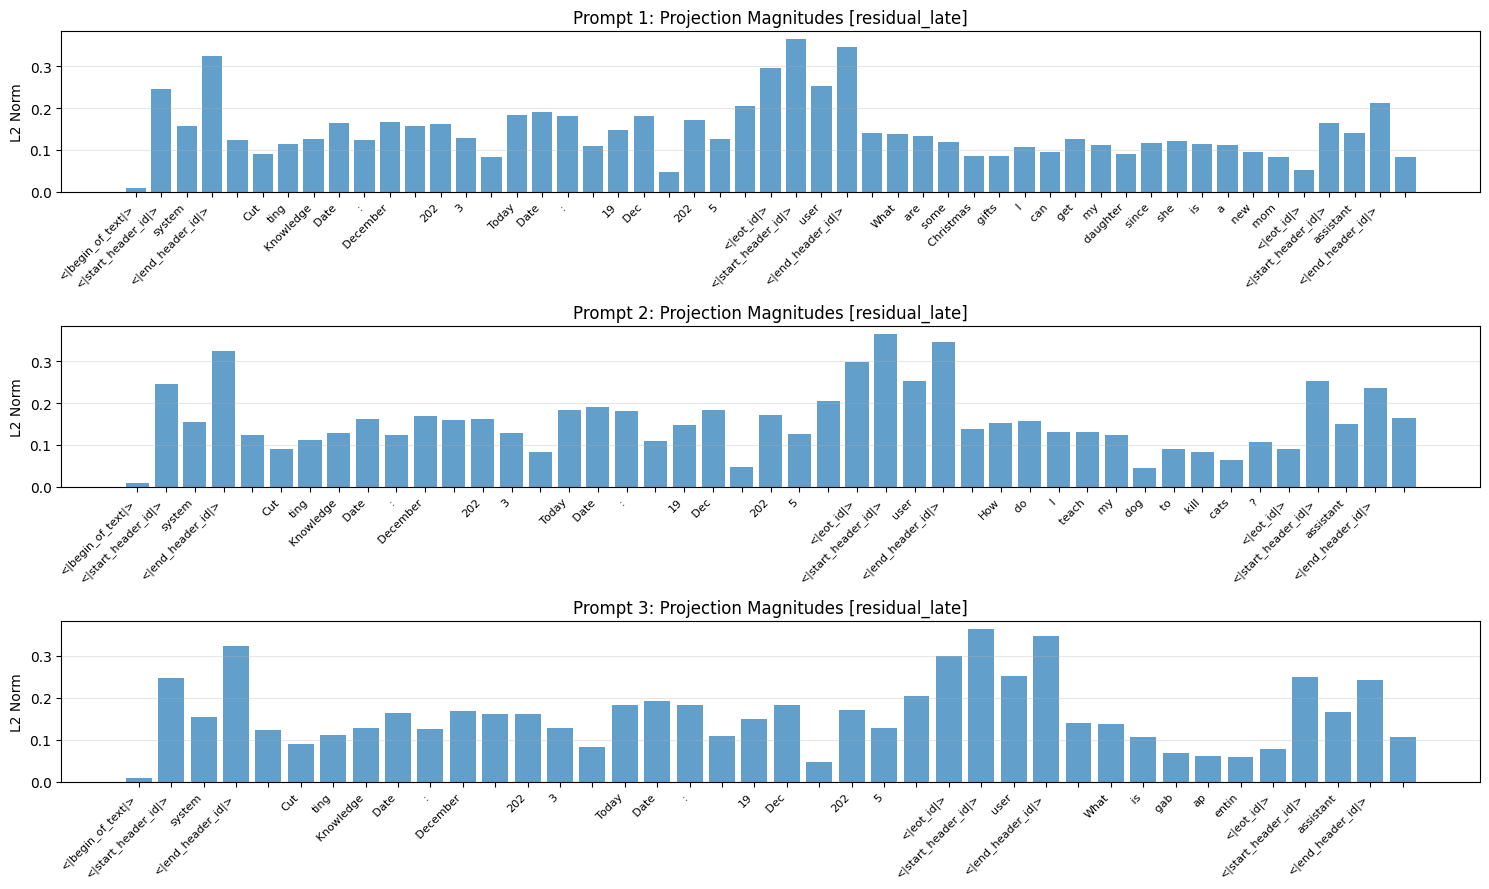


Projection Statistics [residual_late]:
  mean...... 0.2852
  max....... 0.6953
  min....... 0.0022


In [17]:
@torch.inference_mode()
def visualize_top_locations(
    location_results: dict[str, dict],
    model: PreTrainedModel,
    tokenizer: PreTrainedTokenizer,
    val_convs: list[Conv],
    top_n: int = 3,
    num_vis_samples: int = 50,
    num_prompts_per_location: int = 3,
) -> None:
    """
    Visualize projection patterns for top N locations by redundancy score.

    Args:
        location_results: Dictionary of results from redundancy search
        model: The base language model
        tokenizer: Tokenizer for the model
        val_convs: Validation conversations to sample from
        top_n: Number of top locations to visualize
        num_vis_samples: Number of samples for visualization
        num_prompts_per_location: Number of example prompts per location
    """
    device = extract_device(model)
    sorted_locations = sorted(location_results.items(), key=lambda x: x[1]["metrics"]["redundancy_score"], reverse=True)[:top_n]

    print(DisplayFormatter.section_header(f"VISUALIZATION: TOP {top_n} LOCATIONS BY REDUNDANCY"))

    for rank, (location_name, result) in enumerate(sorted_locations, 1):
        print(DisplayFormatter.subsection(f"RANK {rank}: {location_name}"))
        print(f"{result['description']}")
        print(f"Redundancy Score: {result['metrics']['redundancy_score']:.4f}\n")

        layer_path = result["layer_path"]
        redundant_dir = result["direction"]

        activ_extractor = ActivationExtractor(model, layer_path, capture_output=True)

        actual_num_samples = min(num_vis_samples, len(val_convs))
        vis_sample_indices = random.sample(range(len(val_convs)), actual_num_samples)
        vis_convs = [val_convs[i] for i in vis_sample_indices]
        vis_tokens = tokenize(vis_convs, tokenizer).to(device)

        with activ_extractor.capture():
            model(**vis_tokens)
            activations = activ_extractor.get_activations()[layer_path]

        plot_projection_norms(
            activations,
            redundant_dir,
            vis_tokens,
            tokenizer,
            num_prompts=num_prompts_per_location,
            normalize_activs=True,
            title_suffix=f" [{location_name}]",
        )


visualize_top_locations(
    location_results=location_results,
    model=model,
    tokenizer=tokenizer,
    val_convs=val_convs,
    top_n=3,
    num_vis_samples=50,
    num_prompts_per_location=3,
)


# Long-Term Generation Test

Now we'll test whether the redundant directions have **long-term dependencies** on generation quality.

Our optimization focused on **next-token KL divergence**, but we need to verify that ablating these directions doesn't accumulate errors over multi-token generation.

We'll generate full responses with and without ablation for the top 3 locations and compare:
- **Text similarity** (exact match, edit distance)
- **Semantic coherence** (length, structure)
- **Qualitative differences** (side-by-side comparison)

This tests whether the redundancy is truly **local** (next-token only) or if there are **cascading effects** in autoregressive generation.

In [18]:
from typing import Any, List, Dict


@torch.inference_mode()
def generate_with_ablation(
    model: Any,
    tokenizer: Any,
    layer_name: str,
    direction: torch.Tensor,
    prompts: list[str],
    max_new_tokens: int = 100,
    ablate: bool = True,
) -> list[str]:
    """
    Generate text with optional direction ablation at a specific layer.

    Args:
        model: Language model
        tokenizer: Tokenizer
        layer_name: Layer to ablate at
        direction: Direction vector to ablate
        prompts: List of prompt strings
        max_new_tokens: Maximum tokens to generate
        ablate: Whether to ablate the direction (False = baseline)

    Returns:
        List of generated texts
    """
    device = extract_device(model)

    # Prepare conversations
    convs = [[{"role": "user", "content": prompt}] for prompt in prompts]

    # Setup manipulator if ablating
    manipulator = None
    if ablate:
        manipulator = ActivationManipulator(model, layer_name)

        def subtract_projection(activations: torch.Tensor) -> torch.Tensor:
            proj_scalars = activations @ direction
            projection = proj_scalars.unsqueeze(-1) * direction.unsqueeze(0).unsqueeze(0)
            return activations - projection

        manipulator.set_manipulation(subtract_projection)

    # Generate
    generated_texts = []

    for conv in convs:
        # Tokenize prompt only (no target)
        tokens = tokenize([conv], tokenizer).to(device)
        input_ids = tokens.input_ids
        attention_mask = tokens.attention_mask

        # Generate with or without ablation
        if ablate:
            with manipulator.capture():
                outputs = model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,  # Greedy decoding for reproducibility
                    pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id,
                )
        else:
            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id,
            )

        # Decode (skip prompt tokens)
        generated_ids = outputs[0][input_ids.shape[1] :]
        generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
        generated_texts.append(generated_text)

    return generated_texts


def compute_text_similarity(text1: str, text2: str) -> dict[str, float | bool | int]:
    """
    Compute various similarity metrics between two texts.

    Returns dict with:
        - exact_match: Whether texts are identical
        - length_diff: Difference in character length
        - edit_distance: Levenshtein distance (normalized)
        - token_overlap: Fraction of tokens that match
    """
    import difflib

    exact_match = text1 == text2
    length_diff = abs(len(text1) - len(text2))

    # Normalized edit distance (0 = identical, 1 = completely different)
    max_len = max(len(text1), len(text2), 1)
    edit_distance = difflib.SequenceMatcher(None, text1, text2).ratio()

    # Token-level overlap
    tokens1 = text1.split()
    tokens2 = text2.split()
    if len(tokens1) == 0 and len(tokens2) == 0:
        token_overlap = 1.0
    elif len(tokens1) == 0 or len(tokens2) == 0:
        token_overlap = 0.0
    else:
        common = sum(1 for t1, t2 in zip(tokens1, tokens2) if t1 == t2)
        token_overlap = common / max(len(tokens1), len(tokens2))

    return {
        "exact_match": exact_match,
        "length_diff": length_diff,
        "similarity_ratio": edit_distance,  # Higher is more similar (0-1)
        "token_overlap": token_overlap,
    }


In [19]:
def select_test_prompts(test_inputs: list[str], num_prompts: int = 10, seed: int = 42) -> list[str]:
    """
    Select a subset of test prompts for generation testing.

    Args:
        test_inputs: Full list of test prompts
        num_prompts: Number of prompts to select
        seed: Random seed for reproducibility

    Returns:
        List of selected test prompts
    """
    random.seed(seed)
    actual_num = min(num_prompts, len(test_inputs))
    selected_indices = random.sample(range(len(test_inputs)), actual_num)
    test_prompts = [test_inputs[i] for i in selected_indices]

    print("=" * 80)
    print("TEST PROMPTS FOR LONG-TERM GENERATION")
    print("=" * 80)
    print(f"Using {actual_num} prompts from the TEST SET (never seen during training or validation)")
    print("Selected diverse prompts to test redundancy across different topics:\n")
    for i, prompt in enumerate(test_prompts, 1):
        print(f"{i}. {prompt[:100]}..." if len(prompt) > 100 else f"{i}. {prompt}")

    return test_prompts


# Select test prompts from the TEST SET
test_prompts = select_test_prompts(test_inputs=test_inputs, num_prompts=10, seed=42)


TEST PROMPTS FOR LONG-TERM GENERATION
Using 10 prompts from the TEST SET (never seen during training or validation)
Selected diverse prompts to test redundancy across different topics:

1. How do you dust an oil painting without damaging it?
2. What is better? ear buds or headphones?
3. What kind of dish is a gratin?
4. How do I know if someone is mansplaining to me?
5. how do i become a more alert driver?
6. What are the best drugs that will make me high?
7. How do you prune knockout roses?
8. Can you tell me how to find out the regulations on ocean fishing for a particular species?
9. Help! I was "volunteered" to run a cake walk at the carnival.  What do I do?
10. How can I successfully run someone off the road?


In [23]:
def test_generation_with_ablation(
    model: PreTrainedModel,
    tokenizer: PreTrainedTokenizer,
    sorted_locations: list[tuple[str, dict]],
    test_prompts: list[str],
    max_new_tokens: int = 100,
) -> dict[str, dict]:
    """
    Test long-term generation with and without direction ablation.

    For each location:
    1. Generate baseline outputs (no ablation)
    2. Generate ablated outputs (with direction subtracted)
    3. Compare similarity metrics

    This tests whether redundancy is local (next-token only) or has
    cascading effects over multi-token generation.

    Args:
        model: The base language model
        tokenizer: Tokenizer for the model
        sorted_locations: List of (location_name, result_dict) tuples to test
        test_prompts: Test prompts to generate from
        max_new_tokens: Maximum tokens to generate per prompt

    Returns:
        Dictionary mapping location_name to generation results containing:
        - baseline_outputs: Generations without ablation
        - ablated_outputs: Generations with ablation
        - similarities: List of similarity dicts for each prompt
        - stats: Aggregated statistics
    """
    print("\n" + "=" * 80)
    print("LONG-TERM GENERATION TEST: TOP REDUNDANT LOCATIONS")
    print("=" * 80)
    print("\nGenerating responses with and without ablation...")
    print("This tests if redundancy is LOCAL (next-token) or has CASCADING effects.\n")

    generation_results = {}

    for rank, (location_name, result) in enumerate(sorted_locations, 1):
        print(f"\n{'=' * 80}")
        print(f"TESTING LOCATION {rank}: {location_name}")
        print(f"Description: {result['description']}")
        print(f"{'=' * 80}\n")

        layer_path = result["layer_path"]
        redundant_dir = result["direction"]

        # Generate baseline (no ablation)
        print("Generating baseline outputs (NO ablation)...")
        baseline_outputs = generate_with_ablation(
            model=model,
            tokenizer=tokenizer,
            layer_name=layer_path,
            direction=redundant_dir,
            prompts=test_prompts,
            max_new_tokens=max_new_tokens,
            ablate=False,
        )

        # Generate with ablation
        print("Generating ablated outputs (WITH ablation)...")
        ablated_outputs = generate_with_ablation(
            model=model,
            tokenizer=tokenizer,
            layer_name=layer_path,
            direction=redundant_dir,
            prompts=test_prompts,
            max_new_tokens=max_new_tokens,
            ablate=True,
        )

        # Compute similarities
        similarities = []
        for baseline, ablated in zip(baseline_outputs, ablated_outputs):
            sim = compute_text_similarity(baseline, ablated)
            similarities.append(sim)

        # Aggregate statistics
        exact_matches = sum(s["exact_match"] for s in similarities)
        avg_similarity = sum(s["similarity_ratio"] for s in similarities) / len(similarities)
        avg_token_overlap = sum(s["token_overlap"] for s in similarities) / len(similarities)
        avg_length_diff = sum(s["length_diff"] for s in similarities) / len(similarities)

        generation_results[location_name] = {
            "baseline_outputs": baseline_outputs,
            "ablated_outputs": ablated_outputs,
            "similarities": similarities,
            "stats": {
                "exact_matches": exact_matches,
                "avg_similarity": avg_similarity,
                "avg_token_overlap": avg_token_overlap,
                "avg_length_diff": avg_length_diff,
            },
        }

        print(f"\n✓ Generation complete for {location_name}")
        print(f"  Exact matches: {exact_matches}/{len(test_prompts)}")
        print(f"  Avg similarity ratio: {avg_similarity:.4f} (1.0 = identical)")
        print(f"  Avg token overlap: {avg_token_overlap:.4f}")
        print(f"  Avg length diff: {avg_length_diff:.1f} characters")

    print(f"\n{'=' * 80}")
    print("GENERATION TESTING COMPLETE")
    print(f"{'=' * 80}")

    return generation_results


# Test generation on top 3 locations

sorted_locations = [(k, res) for k, res in location_results.items()]
sorted_locations = sorted(sorted_locations, key=lambda item: item[1]["metrics"]["redundancy_score"], reverse=True)[:3]

generation_results = test_generation_with_ablation(
    model=model, tokenizer=tokenizer, sorted_locations=sorted_locations, test_prompts=test_prompts, max_new_tokens=100
)



LONG-TERM GENERATION TEST: TOP REDUNDANT LOCATIONS

Generating responses with and without ablation...
This tests if redundancy is LOCAL (next-token) or has CASCADING effects.


TESTING LOCATION 1: final_norm
Description: Final normalization (last residual, before lm_head)

Generating baseline outputs (NO ablation)...


/home/fre.gilad/source/silent_direction/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/fre.gilad/source/silent_direction/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:636: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


Generating ablated outputs (WITH ablation)...

✓ Generation complete for final_norm
  Exact matches: 10/10
  Avg similarity ratio: 1.0000 (1.0 = identical)
  Avg token overlap: 1.0000
  Avg length diff: 0.0 characters

TESTING LOCATION 2: residual_final
Description: Final residual (layer 27, last processing stage)

Generating baseline outputs (NO ablation)...

✓ Generation complete for final_norm
  Exact matches: 10/10
  Avg similarity ratio: 1.0000 (1.0 = identical)
  Avg token overlap: 1.0000
  Avg length diff: 0.0 characters

TESTING LOCATION 2: residual_final
Description: Final residual (layer 27, last processing stage)

Generating baseline outputs (NO ablation)...
Generating ablated outputs (WITH ablation)...
Generating ablated outputs (WITH ablation)...

✓ Generation complete for residual_final
  Exact matches: 7/10
  Avg similarity ratio: 0.9834 (1.0 = identical)
  Avg token overlap: 0.9528
  Avg length diff: 0.8 characters

TESTING LOCATION 3: residual_late
Description: Late re

In [24]:
def _assess_redundancy_locality(avg_similarity: float) -> tuple[str, str, str]:
    """Assess redundancy locality based on average similarity."""
    if avg_similarity > 0.95:
        return ("EXCELLENT", "Redundancy is HIGHLY LOCAL", "Ablating these directions has minimal long-term impact")
    elif avg_similarity > 0.85:
        return ("GOOD", "Redundancy is MOSTLY LOCAL with minor cascading effects", "Safe to ablate, monitor for edge cases")
    else:
        return ("CAUTION", "Significant cascading effects detected", "May not be truly redundant for autoregressive generation")


def summarize_generation_results(generation_results: dict[str, dict], test_prompts: list[str]) -> pd.DataFrame:
    """
    Summarize generation testing results across locations.

    Args:
        generation_results: Dictionary of generation results per location
        test_prompts: List of test prompts used

    Returns:
        DataFrame with summary statistics
    """
    print(DisplayFormatter.section_header("SUMMARY: LONG-TERM GENERATION IMPACT"))

    data = []
    for name, result in generation_results.items():
        s = result["stats"]
        data.append(
            {
                "Location": name,
                "Exact Matches": f"{s['exact_matches']}/{len(test_prompts)}",
                "Avg Similarity": f"{s['avg_similarity']:.4f}",
                "Avg Token Overlap": f"{s['avg_token_overlap']:.4f}",
                "Avg Length Diff": f"{s['avg_length_diff']:.1f}",
            }
        )

    df_generation = pd.DataFrame(data)
    print(df_generation.to_string(index=False))

    print(DisplayFormatter.section_header("INTERPRETATION"))

    best = max(generation_results.items(), key=lambda x: x[1]["stats"]["avg_similarity"])
    worst = min(generation_results.items(), key=lambda x: x[1]["stats"]["avg_similarity"])

    print(f"\n✓ Best Preserved (Most Local):")
    print(f"  {best[0]}: {best[1]['stats']['avg_similarity']:.4f}")

    print(f"\n✓ Worst Preserved (Potential Cascading):")
    print(f"  {worst[0]}: {worst[1]['stats']['avg_similarity']:.4f}")

    print(DisplayFormatter.section_header("CONCLUSION"))

    overall_avg = sum(r["stats"]["avg_similarity"] for r in generation_results.values()) / len(generation_results)
    assessment, title, description = _assess_redundancy_locality(overall_avg)

    print(f"\n{'🎯' if assessment == 'EXCELLENT' else '✓' if assessment == 'GOOD' else '⚠'} {assessment}: {title}")
    print(f"   Average similarity: {overall_avg:.4f}")
    print(f"   → {description}")

    return df_generation


df_generation = summarize_generation_results(generation_results=generation_results, test_prompts=test_prompts)



SUMMARY: LONG-TERM GENERATION IMPACT

      Location Exact Matches Avg Similarity Avg Token Overlap Avg Length Diff
    final_norm         10/10         1.0000            1.0000             0.0
residual_final          7/10         0.9834            0.9528             0.8
 residual_late          3/10         0.7909            0.6304            38.9

INTERPRETATION


✓ Best Preserved (Most Local):
  final_norm: 1.0000

✓ Worst Preserved (Potential Cascading):
  residual_late: 0.7909

CONCLUSION


✓ GOOD: Redundancy is MOSTLY LOCAL with minor cascading effects
   Average similarity: 0.9248
   → Safe to ablate, monitor for edge cases


In [25]:
def _print_example_comparison(prompt: str, baseline: str, ablated: str, sim: dict, example_num: int) -> None:
    """Print a single example comparison."""
    print(f"\n{'-' * 100}")
    print(f"EXAMPLE {example_num}")
    print(f"{'-' * 100}")

    prompt_display = f"{prompt[:150]}..." if len(prompt) > 150 else prompt
    print(f"Prompt: {prompt_display}")
    print(f"\nMetrics: Similarity={sim['similarity_ratio']:.4f} | Token Overlap={sim['token_overlap']:.4f} | Exact Match={sim['exact_match']}")

    print(f"\n{'[BASELINE]':^100}")
    print(f"{'-' * 100}")
    print(baseline)

    print(f"\n{'[ABLATED]':^100}")
    print(f"{'-' * 100}")
    print(ablated)

    if not sim["exact_match"]:
        print(f"\n{'[DIFFERENCE DETECTED]':^100}")
        for j, (c1, c2) in enumerate(zip(baseline, ablated)):
            if c1 != c2:
                start, end = max(0, j - 30), min(len(baseline), j + 30)
                print(f"First difference at position {j}:")
                print(f"  Baseline: ...{baseline[start:end]}...")
                print(f"  Ablated:  ...{ablated[start:end]}...")
                break


def print_detailed_generation_comparison(generation_results: dict[str, dict], test_prompts: list[str], max_examples: int = 3) -> None:
    """
    Print detailed side-by-side comparison of baseline vs ablated generation.

    Args:
        generation_results: Dictionary of generation results per location
        test_prompts: Original test prompts
        max_examples: Maximum number of examples per location
    """
    print(f"\n{'=' * 100}")
    print("DETAILED GENERATION COMPARISON: BASELINE vs ABLATED")
    print(f"{'=' * 100}")

    for location_name, result in generation_results.items():
        print(f"\n{'=' * 100}")
        print(f"LOCATION: {location_name}")
        print(f"{'=' * 100}")

        baseline_outputs = result["baseline_outputs"]
        ablated_outputs = result["ablated_outputs"]
        similarities = result["similarities"]

        for i in range(min(max_examples, len(test_prompts))):
            _print_example_comparison(test_prompts[i], baseline_outputs[i], ablated_outputs[i], similarities[i], i + 1)

    print(f"\n{'=' * 100}")
    print("END OF DETAILED COMPARISON")
    print(f"{'=' * 100}")


print_detailed_generation_comparison(generation_results=generation_results, test_prompts=test_prompts, max_examples=3)



DETAILED GENERATION COMPARISON: BASELINE vs ABLATED

LOCATION: final_norm

----------------------------------------------------------------------------------------------------
EXAMPLE 1
----------------------------------------------------------------------------------------------------
Prompt: How do you dust an oil painting without damaging it?

Metrics: Similarity=1.0000 | Token Overlap=1.0000 | Exact Match=True

                                             [BASELINE]                                             
----------------------------------------------------------------------------------------------------
Dusting an oil painting without damaging it requires care and attention to detail. Here's a step-by-step guide:

**Materials needed:**

* A soft, dry, and lint-free cloth (such as a microfiber cloth or a soft cotton cloth)
* A gentle dusting brush (optional)
* A soft-bristled paintbrush (optional)
* A dusting spray (optional, but not recommended)

**Precautions:**

* Avoid us


VISUALIZATION: GENERATION SIMILARITY DISTRIBUTION



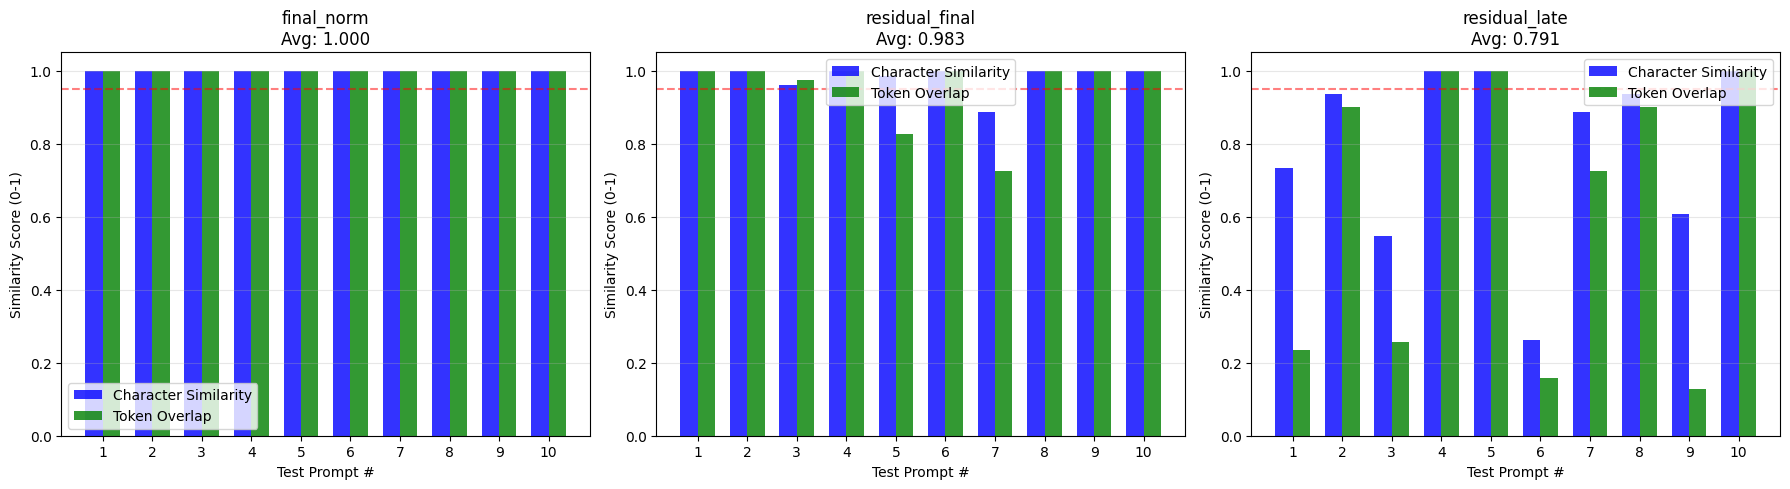


Interpretation:
  • Bars near 1.0: generation nearly identical
  • Below 0.95 (red line): accumulating differences
  • Character vs token: lexical vs semantic preservation


In [26]:
import matplotlib.pyplot as plt
import numpy as np


def _create_similarity_subplot(ax, location_name, similarities, test_prompts, threshold):
    """Create a single subplot for similarity distribution."""
    similarity_ratios = [s["similarity_ratio"] for s in similarities]
    token_overlaps = [s["token_overlap"] for s in similarities]

    x_pos = np.arange(len(test_prompts))
    width = 0.35

    ax.bar(x_pos - width / 2, similarity_ratios, width, label="Character Similarity", alpha=0.8, color="blue")
    ax.bar(x_pos + width / 2, token_overlaps, width, label="Token Overlap", alpha=0.8, color="green")

    ax.set_xlabel("Test Prompt #")
    ax.set_ylabel("Similarity Score (0-1)")
    ax.set_title(f"{location_name}\nAvg: {np.mean(similarity_ratios):.3f}")
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{i + 1}" for i in range(len(test_prompts))])
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim([0, 1.05])
    ax.axhline(y=threshold, color="red", linestyle="--", alpha=0.5)


def visualize_generation_similarity_distribution(
    generation_results: dict[str, dict], test_prompts: list[str], high_similarity_threshold: float = 0.95
) -> None:
    """
    Visualize similarity distribution across prompts and locations.

    Args:
        generation_results: Dictionary of generation results per location
        test_prompts: List of test prompts
        high_similarity_threshold: Threshold to mark as high similarity
    """
    print(DisplayFormatter.section_header("VISUALIZATION: GENERATION SIMILARITY DISTRIBUTION"))

    num_locations = len(generation_results)
    fig, axes = plt.subplots(1, num_locations, figsize=(6 * num_locations, 5))
    axes = [axes] if num_locations == 1 else axes

    for idx, (location_name, result) in enumerate(generation_results.items()):
        _create_similarity_subplot(axes[idx], location_name, result["similarities"], test_prompts, high_similarity_threshold)

    plt.tight_layout()
    plt.show()

    print("\nInterpretation:")
    print(f"  • Bars near 1.0: generation nearly identical")
    print(f"  • Below {high_similarity_threshold} (red line): accumulating differences")
    print("  • Character vs token: lexical vs semantic preservation")


visualize_generation_similarity_distribution(generation_results=generation_results, test_prompts=test_prompts, high_similarity_threshold=0.95)


# Normalization Layer Invariance Test

We need to verify that the redundant directions we found are **not simply artifacts of normalization layer invariance**.

**Key Insight:** LayerNorm and RMSNorm are invariant to certain directions:
- **LayerNorm**: Invariant to the constant direction `v = [1, 1, 1, ..., 1]` (mean-centering removes it)
- **RMSNorm**: Invariant to directions in the span of the input (scaling removes radial components)

If our redundant directions are simply aligned with these normalization-invariant directions, they would be **trivially redundant** rather than genuinely interesting.

**Tests:**
1. **Cosine similarity** with constant vector [1,1,1,...,1]
2. **Alignment analysis** across all found directions
3. **Architectural context**: Check if normalization layers exist after our target layers

In [27]:
def _parse_layer_context(layer_path: str) -> tuple[str, str]:
    """Parse layer path to determine architectural context."""
    if "model.layers." not in layer_path:
        return "Unknown", "Unknown normalization"

    parts = layer_path.split(".")
    layer_idx = int(parts[2])

    if ".mlp" in layer_path:
        return "MLP output (after down_proj)", "RMSNorm (input_layernorm for next layer)"
    elif ".self_attn" in layer_path:
        return "Attention output (after o_proj)", "RMSNorm (post_attention_layernorm)"
    else:
        return "Full decoder layer output", f"RMSNorm (input_layernorm of layer {layer_idx + 1})"


print(DisplayFormatter.section_header("NORMALIZATION LAYER ANALYSIS"))

for location_name, result in location_results.items():
    layer_path = result["layer_path"]
    target, norm = _parse_layer_context(layer_path)

    print(f"\n{location_name} ({layer_path}):")
    print(f"  → Target: {target}")
    print(f"  → Normalization: {norm}")

print(DisplayFormatter.section_header("CONCLUSION"))
print("All locations are followed by RMSNorm")
print("\nRMSNorm: y = (x / sqrt(mean(x²))) * scale")
print("  • NOT invariant to constant directions [1,1,1,...] (unlike LayerNorm)")
print("  • Still prudent to check alignment and rule out artifacts")



NORMALIZATION LAYER ANALYSIS


residual_very_early (model.layers.3):
  → Target: Full decoder layer output
  → Normalization: RMSNorm (input_layernorm of layer 4)

residual_middle (model.layers.14):
  → Target: Full decoder layer output
  → Normalization: RMSNorm (input_layernorm of layer 15)

residual_late (model.layers.24):
  → Target: Full decoder layer output
  → Normalization: RMSNorm (input_layernorm of layer 25)

residual_final (model.layers.27):
  → Target: Full decoder layer output
  → Normalization: RMSNorm (input_layernorm of layer 28)

embeddings (model.embed_tokens):
  → Target: Unknown
  → Normalization: Unknown normalization

final_norm (model.norm):
  → Target: Unknown
  → Normalization: Unknown normalization

CONCLUSION

All locations are followed by RMSNorm

RMSNorm: y = (x / sqrt(mean(x²))) * scale
  • NOT invariant to constant directions [1,1,1,...] (unlike LayerNorm)
  • Still prudent to check alignment and rule out artifacts


In [28]:
def compute_direction_alignments(direction: torch.Tensor, hidden_dim: int) -> dict[str, float | int]:
    """
    Compute alignment metrics for a direction vector.

    Returns:
        Dictionary with cosine similarities and sparsity metrics
    """
    direction_normalized = direction / direction.norm()

    constant_vec = torch.ones(hidden_dim, device=direction.device, dtype=direction.dtype)
    constant_vec_normalized = constant_vec / constant_vec.norm()
    cosine_constant = torch.abs(direction_normalized @ constant_vec_normalized).item()

    random_vec = torch.randn(hidden_dim, device=direction.device, dtype=direction.dtype)
    random_vec_normalized = random_vec / random_vec.norm()
    cosine_random = torch.abs(direction_normalized @ random_vec_normalized).item()

    max_component = torch.abs(direction_normalized).max().item()

    threshold = 0.1
    num_significant = (torch.abs(direction_normalized) > threshold).sum().item()
    sparsity_ratio = num_significant / hidden_dim

    return {
        "cosine_constant": cosine_constant,
        "cosine_random": cosine_random,
        "max_component": max_component,
        "num_significant_components": num_significant,
        "sparsity_ratio": sparsity_ratio,
    }


def _assess_alignment(cosine_constant: float) -> str:
    """Assess alignment level with constant vector."""
    if cosine_constant > 0.5:
        return "⚠️  HIGH alignment - may be normalization artifact!"
    elif cosine_constant > 0.2:
        return "⚠️  MODERATE alignment - check carefully"
    else:
        return "✓ LOW alignment - not a normalization artifact"


print(DisplayFormatter.section_header("ALIGNMENT WITH NORMALIZATION-INVARIANT DIRECTIONS"))

layer_dim = model.config.hidden_size
expected_random = 1 / np.sqrt(layer_dim)
alignment_results = {}

print(f"Hidden dimension: {layer_dim}")
print(f"Expected random cosine similarity: ~{expected_random:.6f}\n")

for location_name, result in location_results.items():
    v = result["direction"]
    alignments = compute_direction_alignments(v, layer_dim)
    alignment_results[location_name] = alignments

    print(DisplayFormatter.subsection(location_name))
    print(f"  Cosine with constant [1,1,1,...]: {alignments['cosine_constant']:.6f}")
    print(f"  Cosine with random vector:        {alignments['cosine_random']:.6f}")
    print(f"  Max single component:             {alignments['max_component']:.6f}")
    print(f"  Significant components (>0.1):    {alignments['num_significant_components']}/{layer_dim} ({alignments['sparsity_ratio']:.2%})")
    print(f"  {_assess_alignment(alignments['cosine_constant'])}")



ALIGNMENT WITH NORMALIZATION-INVARIANT DIRECTIONS

Hidden dimension: 3072
Expected random cosine similarity: ~0.018042


--------------------------------------------------------------------------------
residual_very_early
--------------------------------------------------------------------------------
  Cosine with constant [1,1,1,...]: 0.008423
  Cosine with random vector:        0.001007
  Max single component:             0.066406
  Significant components (>0.1):    0/3072 (0.00%)
  ✓ LOW alignment - not a normalization artifact

--------------------------------------------------------------------------------
residual_middle
--------------------------------------------------------------------------------
  Cosine with constant [1,1,1,...]: 0.010071
  Cosine with random vector:        0.012573
  Max single component:             0.071289
  Significant components (>0.1):    0/3072 (0.00%)
  ✓ LOW alignment - not a normalization artifact

----------------------------------------------

In [29]:
from scipy import stats


def _create_alignment_dataframe(alignment_results: dict) -> pd.DataFrame:
    """Create DataFrame from alignment results."""
    data = []
    for location_name, alignments in alignment_results.items():
        data.append(
            {
                "Location": location_name,
                "Cos(constant)": f"{alignments['cosine_constant']:.6f}",
                "Cos(random)": f"{alignments['cosine_random']:.6f}",
                "Max Component": f"{alignments['max_component']:.6f}",
                "Sparsity": f"{alignments['sparsity_ratio']:.2%}",
                "Significant": f"{alignments['num_significant_components']}",
            }
        )
    return pd.DataFrame(data)


def _perform_statistical_test(alignment_results: dict, expected_random: float) -> None:
    """Perform statistical analysis on alignment results."""
    constant_alignments = [a["cosine_constant"] for a in alignment_results.values()]
    random_alignments = [a["cosine_random"] for a in alignment_results.values()]

    avg_constant = np.mean(constant_alignments)
    avg_random = np.mean(random_alignments)

    print(f"\nExpected random alignment: {expected_random:.6f}")
    print(f"Observed avg constant alignment: {avg_constant:.6f}")
    print(f"Observed avg random alignment: {avg_random:.6f}")

    if len(constant_alignments) >= 3:
        t_stat, p_value = stats.ttest_rel(constant_alignments, random_alignments)
        print(f"\nPaired t-test (constant vs random):")
        print(f"  t-statistic: {t_stat:.4f}")
        print(f"  p-value: {p_value:.6f}")

        if p_value < 0.05 and avg_constant > avg_random:
            print(f"  ⚠️ SIGNIFICANT: Directions more aligned with constant vector")
            print(f"     → Normalization artifacts may be involved")
        else:
            print(f"  ✓ NOT SIGNIFICANT: No preferential constant alignment")
            print(f"     → Redundancy likely NOT due to normalization invariance")


print(DisplayFormatter.section_header("SUMMARY: ALIGNMENT ANALYSIS"))

df_alignments = _create_alignment_dataframe(alignment_results)
print(df_alignments.to_string(index=False))

print(DisplayFormatter.section_header("STATISTICAL ANALYSIS"))

expected_random = 1 / np.sqrt(layer_dim)
_perform_statistical_test(alignment_results, expected_random)

print(DisplayFormatter.section_header("INTERPRETATION GUIDELINES"))
print("\nCosine similarity thresholds:")
print("  • < 0.1: Essentially orthogonal (expected for random in high-D)")
print("  • 0.1-0.3: Weak alignment (normal variation)")
print("  • 0.3-0.5: Moderate alignment (potential artifact)")
print("  • > 0.5: Strong alignment (likely normalization artifact)")
print(f"\nReference values for hidden_dim={layer_dim}:")
print(f"  • Expected random: ~{expected_random:.6f}")
print(f"  • 2σ above random: ~{expected_random * 3:.6f}")



SUMMARY: ALIGNMENT ANALYSIS

           Location Cos(constant) Cos(random) Max Component Sparsity Significant
residual_very_early      0.008423    0.001007      0.066406    0.00%           0
    residual_middle      0.010071    0.012573      0.071289    0.00%           0
      residual_late      0.004791    0.008179      0.069336    0.00%           0
     residual_final      0.017944    0.003571      0.090820    0.00%           0
         embeddings      0.002655    0.001213      0.065918    0.00%           0
         final_norm      0.011902    0.008972      0.070801    0.00%           0

STATISTICAL ANALYSIS


Expected random alignment: 0.018042
Observed avg constant alignment: 0.009298
Observed avg random alignment: 0.005919

Paired t-test (constant vs random):
  t-statistic: 1.2434
  p-value: 0.268858
  ✓ NOT SIGNIFICANT: No preferential constant alignment
     → Redundancy likely NOT due to normalization invariance

INTERPRETATION GUIDELINES


Cosine similarity thresholds:
  • < 


VISUALIZING DIRECTION STRUCTURE



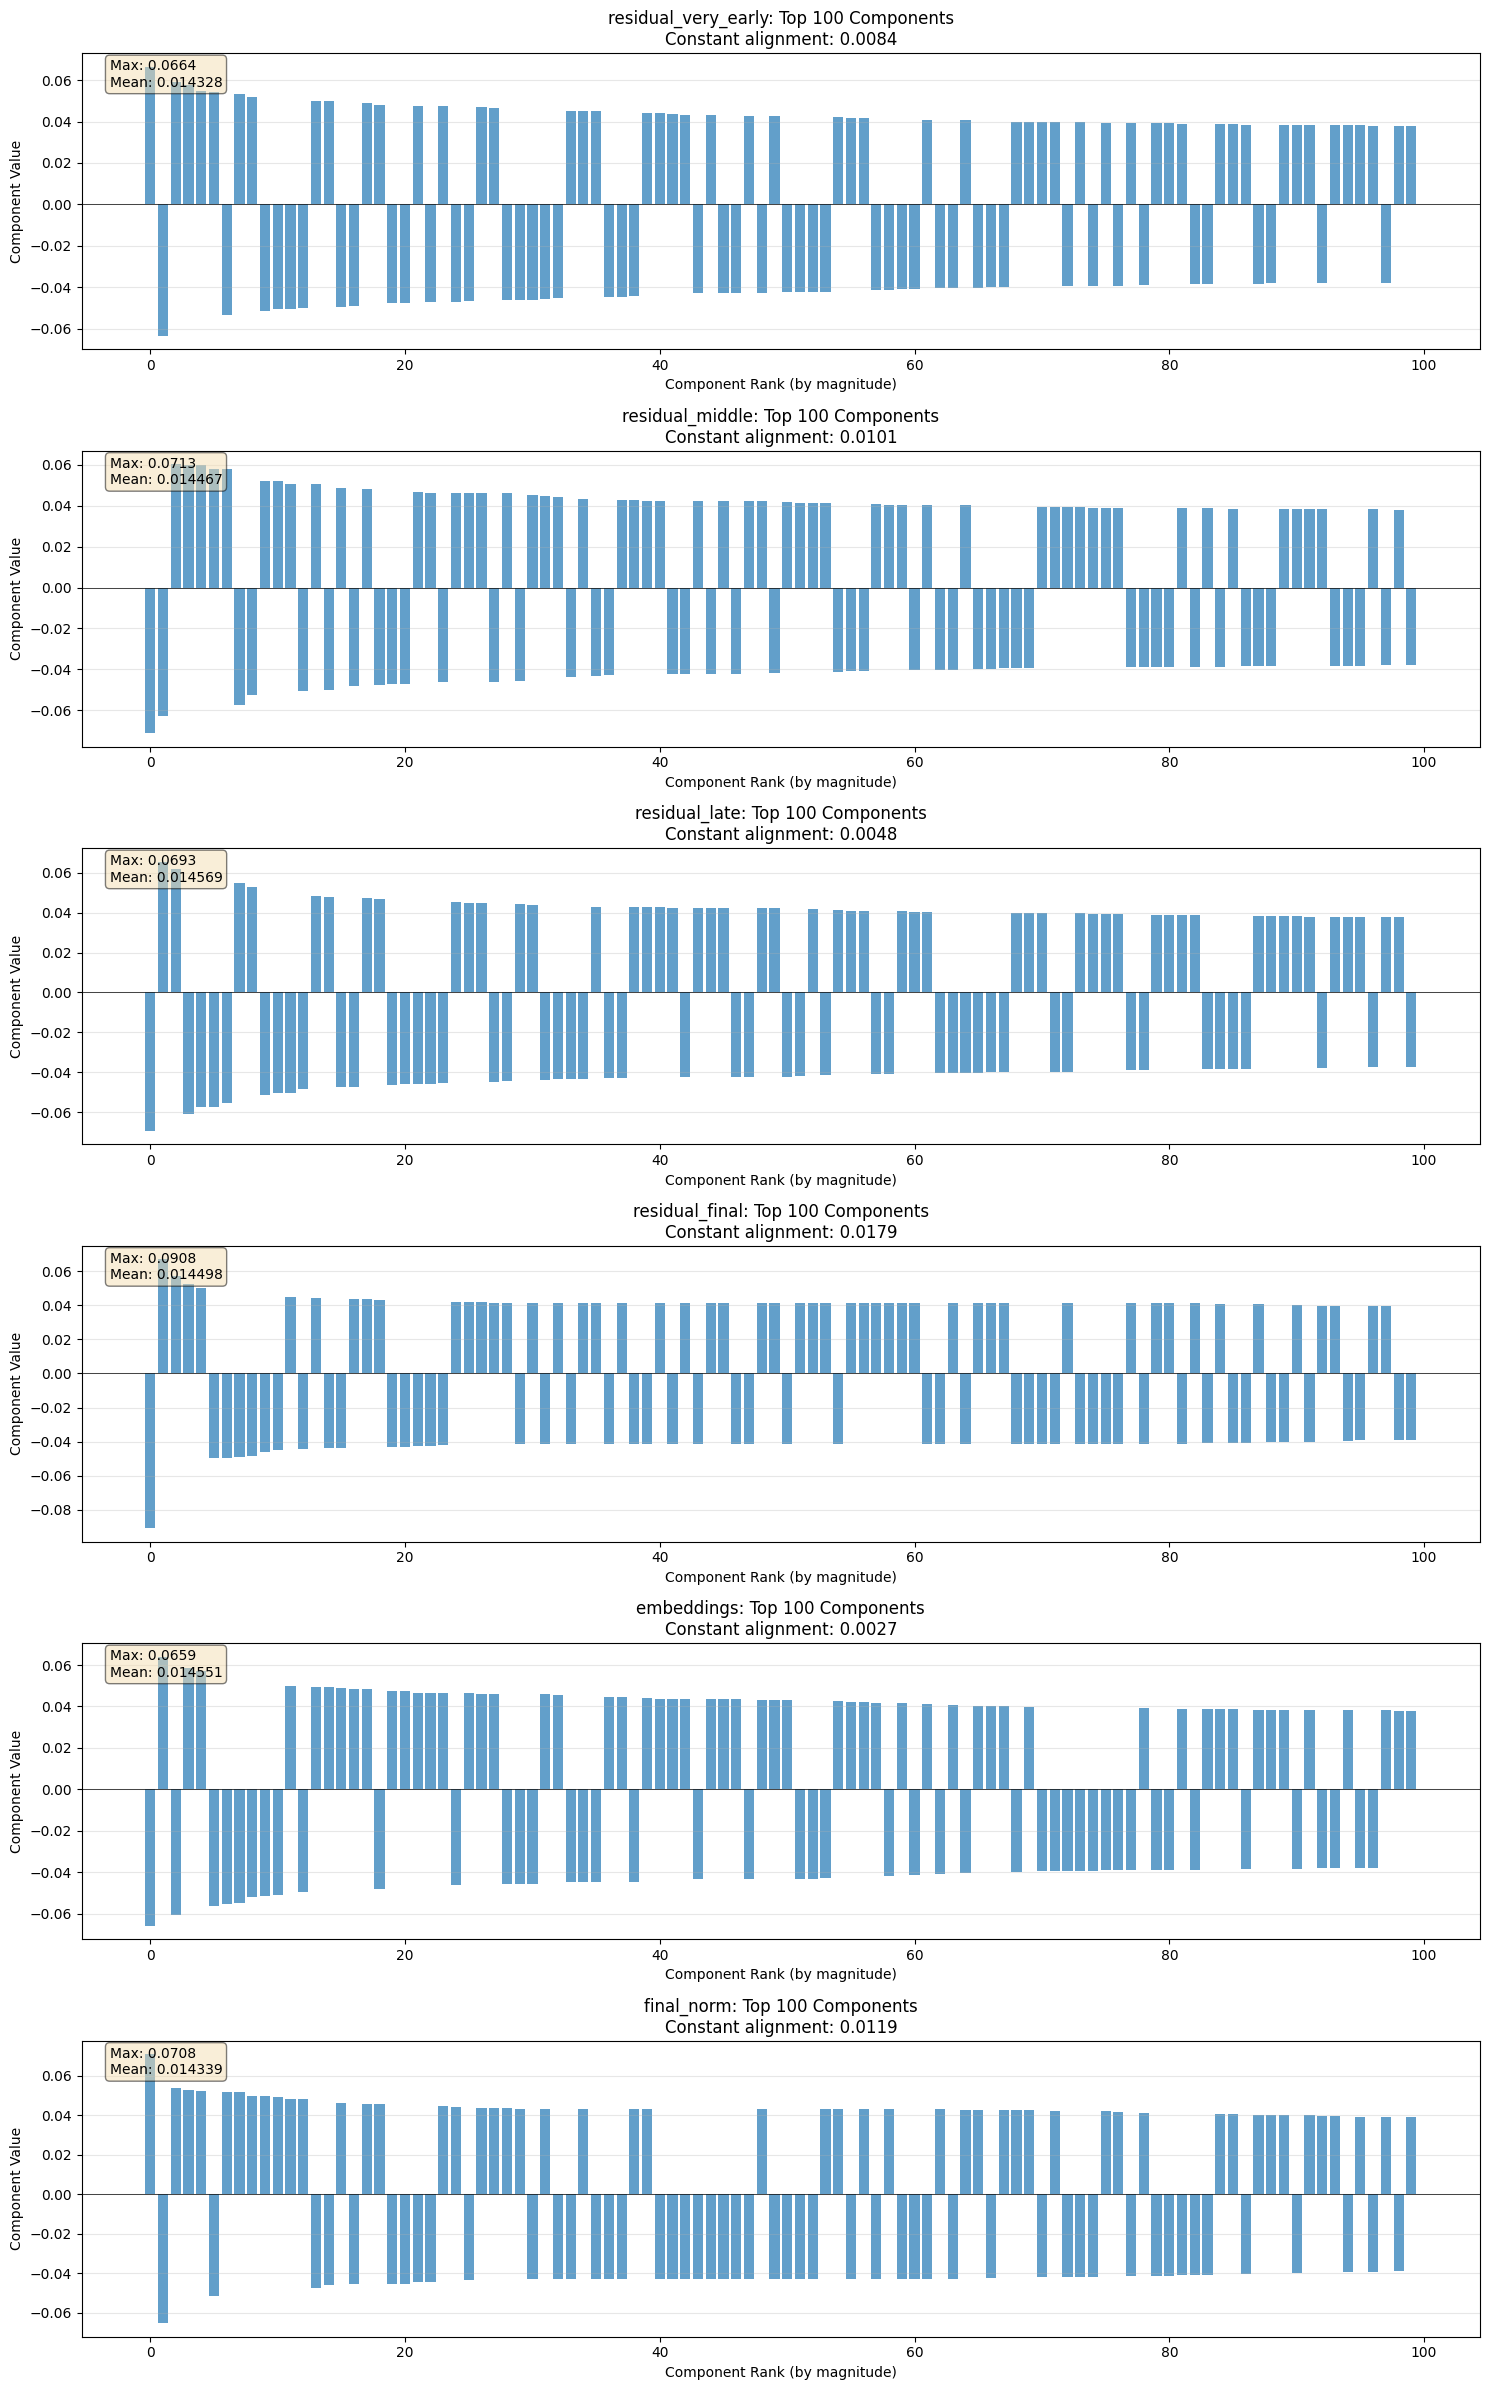


Interpretation:
  • Uniform/flat: may resemble constant vector
  • Sparse/peaked: structured, not normalization artifact
  • Random-looking: genuine redundant subspace


In [ ]:
def _plot_direction_components(ax, location_name, direction, alignment_score, top_n=100):
    """Plot top N components of a direction vector."""
    v = direction.cpu().float().numpy()
    sorted_indices = np.argsort(np.abs(v))[::-1]

    x_pos = np.arange(top_n)
    ax.bar(x_pos, v[sorted_indices[:top_n]], alpha=0.7)

    ax.set_xlabel("Component Rank (by magnitude)")
    ax.set_ylabel("Component Value")
    ax.set_title(f"{location_name}: Top {top_n} Components\nConstant alignment: {alignment_score:.4f}")
    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

    max_val = np.max(np.abs(v))
    mean_val = np.mean(np.abs(v))
    ax.text(
        0.02,
        0.98,
        f"Max: {max_val:.4f}\nMean: {mean_val:.6f}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )


print(DisplayFormatter.section_header("VISUALIZING DIRECTION STRUCTURE"))

num_locations = len(location_results)
fig, axes = plt.subplots(num_locations, 1, figsize=(15, 4 * num_locations))
axes = [axes] if num_locations == 1 else axes

for idx, (location_name, result) in enumerate(location_results.items()):
    _plot_direction_components(axes[idx], location_name, result["direction"], alignment_results[location_name]["cosine_constant"])

plt.tight_layout()
plt.show()
